# SPY Hybrid QRNN SI Cross-lagged

Original unrestricted model tuning with seven separately estimated quantile levels and rank-based model selection.

In [1]:
# ============================================================
# SPY MODELLING DATA PREPARATION
# Common setup for all ERNN and QRNN specifications
# ============================================================

from pathlib import Path
import random
import numpy as np
import pandas as pd
import torch


# ------------------------------------------------------------
# 1. Reproducibility and device
# ------------------------------------------------------------

BASE_SEED = 2026

random.seed(BASE_SEED)
np.random.seed(BASE_SEED)
torch.manual_seed(BASE_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(BASE_SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# ------------------------------------------------------------
# 2. Load the scaled SPY dataset
# ------------------------------------------------------------

DATA_PATH = Path.home() / "SPY_features_scaled.csv"

df = pd.read_csv(
    DATA_PATH,
    index_col="Date",
    parse_dates=True
)

df = (
    df
    .sort_index()
    .drop_duplicates()
    .dropna()
    .copy()
)


# ------------------------------------------------------------
# 3. Response and predictors
# ------------------------------------------------------------

target_col = "log_return"

feature_cols = [
    "Volatility",
    "RSI_14",
    "ATR_14",
    "QQQ_LogReturns",
    "VIX_LogChange",
    "Volume_LogChange",
]

required_cols = [target_col] + feature_cols

missing_cols = [
    column
    for column in required_cols
    if column not in df.columns
]

if missing_cols:
    raise ValueError(
        "Missing required columns: "
        + ", ".join(missing_cols)
    )


# ------------------------------------------------------------
# 4. Chronological 70%-15%-15% split
# ------------------------------------------------------------

train_size = int(len(df) * 0.70)
val_size = int(len(df) * 0.15)

train_df = df.iloc[:train_size].copy()
val_df = df.iloc[train_size:train_size + val_size].copy()
test_df = df.iloc[train_size + val_size:].copy()


# ------------------------------------------------------------
# 5. Convert samples to tensors
# ------------------------------------------------------------

def dataframe_to_tensors(sample):
    X = torch.tensor(
        sample[feature_cols].to_numpy(),
        dtype=torch.float32,
        device=device
    )
    y = torch.tensor(
        sample[target_col].to_numpy(),
        dtype=torch.float32,
        device=device
    )
    return X, y


X_train, y_train = dataframe_to_tensors(train_df)
X_val, y_val = dataframe_to_tensors(val_df)
X_test, y_test = dataframe_to_tensors(test_df)

# Compatibility aliases used by later QRNN cells.
X_test_q = X_test
y_test_q = y_test

levels = [
    0.025,
    0.050,
    0.250,
    0.500,
    0.750,
    0.950,
    0.975,
]

alpha_levels = levels
tau_levels = levels


# ------------------------------------------------------------
# 6. Checks and split summary
# ------------------------------------------------------------

assert len(X_train) == len(y_train)
assert len(X_val) == len(y_val)
assert len(X_test) == len(y_test)
assert X_train.shape[1] == len(feature_cols)
assert torch.isfinite(X_train).all()
assert torch.isfinite(X_val).all()
assert torch.isfinite(X_test).all()
assert torch.isfinite(y_train).all()
assert torch.isfinite(y_val).all()
assert torch.isfinite(y_test).all()

split_summary = pd.DataFrame({
    "Sample": ["Training", "Validation", "Test"],
    "Observations": [len(train_df), len(val_df), len(test_df)],
    "Start": [
        train_df.index.min().date(),
        val_df.index.min().date(),
        test_df.index.min().date(),
    ],
    "End": [
        train_df.index.max().date(),
        val_df.index.max().date(),
        test_df.index.max().date(),
    ],
})

display(split_summary)

print("Input features:", feature_cols)
print("Number of predictors:", len(feature_cols))
print("X_train shape:", tuple(X_train.shape))
print("X_val shape:  ", tuple(X_val.shape))
print("X_test shape: ", tuple(X_test.shape))


Device: cpu


,Sample,Observations,Start,End
0,Training,2219,2014-01-23,2022-11-11
1,Validation,475,2022-11-14,2024-10-04
2,Test,476,2024-10-07,2026-08-31


Input features: ['Volatility', 'RSI_14', 'ATR_14', 'QQQ_LogReturns', 'VIX_LogChange', 'Volume_LogChange']
Number of predictors: 6
X_train shape: (2219, 6)
X_val shape:   (475, 6)
X_test shape:  (476, 6)


## Original tuning

Run after the preparation cell.

In [3]:
# ============================================================
# ORIGINAL TUNING — SPY HYBRID QRNN SI CROSS-LAGGED
# Seven separately estimated levels; 200 Optuna trials per level
# ============================================================

import copy
import json
import time

import optuna
import torch.nn as nn
import torch.nn.functional as F
from optuna.samplers import TPESampler


MODEL_NAME = "spy_qrnn_si_cross"
FORM = "SI"
LAG_TYPE = "cross"
N_TRIALS = 200
MAX_EPOCHS = 200

ALPHA_LEVELS = [
    0.025, 0.050, 0.250, 0.500,
    0.750, 0.950, 0.975,
]

OUTPUT_DIR = Path("spy_original_tuning_results") / MODEL_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Model:", MODEL_NAME)
print("Output directory:", OUTPUT_DIR.resolve())


def set_model_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def hybrid_qrnn_loss(y, q_hybrid, sigma_al, alpha):
    """Mean asymmetric-Laplace negative log-likelihood."""
    eps = torch.finfo(q_hybrid.dtype).eps
    sigma_al = torch.clamp(sigma_al, min=eps)
    alpha_tensor = torch.as_tensor(
        alpha,
        dtype=q_hybrid.dtype,
        device=q_hybrid.device
    )
    residual = y - q_hybrid
    indicator = (residual < 0).to(q_hybrid.dtype)
    check_loss = residual * (alpha_tensor - indicator)
    nll = (
        -torch.log(alpha_tensor * (1.0 - alpha_tensor))
        + torch.log(sigma_al)
        + check_loss / sigma_al
    )
    return nll.mean()


def compute_hybrid_location(y, X, beta1, beta2, beta3, fnn, psi):
    """SI-form cross-lagged CAViaR-hybrid recursion."""
    fnn_output = fnn(X).squeeze(-1)
    zero_value = y.new_zeros(())
    statistical_forecasts = [zero_value]
    hybrid_forecasts = [zero_value]

    for time_index in range(1, len(y)):
        previous_return = y[time_index - 1]
        previous_state = hybrid_forecasts[time_index - 1]
        absolute_return = torch.abs(previous_return)
        statistical_value = (
            beta1 * previous_state
            + beta2 * absolute_return
            + beta3 * previous_state * absolute_return
        )
        hybrid_value = (
            psi * statistical_value
            + (1.0 - psi) * fnn_output[time_index]
        )
        statistical_forecasts.append(statistical_value)
        hybrid_forecasts.append(hybrid_value)

    return (
        torch.stack(hybrid_forecasts),
        torch.stack(statistical_forecasts),
    )


class HybridQRNN_SI_Cross(nn.Module):
    def __init__(self, input_dim, config):
        super().__init__()
        self.eps = 1e-6
        self.beta1_raw = nn.Parameter(torch.tensor(1.386))
        self.beta2_raw = nn.Parameter(torch.tensor(0.3))
        self.beta3_raw = nn.Parameter(
            torch.tensor(0.3)
        )
        self.psi_raw = nn.Parameter(torch.tensor(0.0))
        self.sigma_raw = nn.Parameter(torch.tensor(0.5))

        layers = []
        previous_dimension = input_dim
        for layer_index in range(config["n_hidden_layers"]):
            hidden_dimension = config[f"hidden_dim_{layer_index}"]
            layers.append(nn.Linear(previous_dimension, hidden_dimension))
            if config["layernorm"]:
                layers.append(nn.LayerNorm(hidden_dimension))
            layers.append(self.get_activation(config["activation"]))
            if config["dropout"] > 0:
                layers.append(nn.Dropout(config["dropout"]))
            previous_dimension = hidden_dimension
        layers.append(nn.Linear(previous_dimension, 1))
        self.fnn = nn.Sequential(*layers)
        self.initialise_weights(config["weight_init"])

    @staticmethod
    def get_activation(name):
        return {
            "relu": nn.ReLU(),
            "elu": nn.ELU(),
            "gelu": nn.GELU(),
            "tanh": nn.Tanh(),
        }[name]

    def initialise_weights(self, method):
        for module in self.fnn.modules():
            if not isinstance(module, nn.Linear):
                continue
            if method == "glorot":
                nn.init.xavier_uniform_(module.weight)
            else:
                nn.init.kaiming_uniform_(module.weight)
            if module.bias is not None:
                nn.init.zeros_(module.bias)

    def forward(self, y, X):
        beta1 = torch.sigmoid(self.beta1_raw)
        beta2 = F.softplus(self.beta2_raw)
        beta3 = F.softplus(
            self.beta3_raw
        )
        psi = torch.sigmoid(self.psi_raw)
        sigma = F.softplus(self.sigma_raw) + self.eps
        hybrid, statistical = compute_hybrid_location(
            y, X, beta1, beta2, beta3, self.fnn, psi
        )
        return hybrid, sigma, statistical


def calculate_crp(y, forecast, alpha):
    if alpha <= 0.5:
        empirical = (y <= forecast).float().mean().item()
        target = alpha
    else:
        empirical = (y > forecast).float().mean().item()
        target = 1.0 - alpha
    crp = empirical / target
    return crp, (crp - 1.0) ** 2, empirical


def suggest_config(trial):
    config = {
        "n_hidden_layers": trial.suggest_int("n_hidden_layers", 1, 3),
        "activation": trial.suggest_categorical(
            "activation", ["relu", "elu", "gelu", "tanh"]
        ),
        "dropout": trial.suggest_float("dropout", 0.0, 0.5),
        "layernorm": trial.suggest_categorical("layernorm", [True, False]),
        "weight_init": trial.suggest_categorical(
            "weight_init", ["glorot", "he"]
        ),
        "lr": trial.suggest_float("lr", 1e-4, 5e-2, log=True),
        "optimizer": trial.suggest_categorical(
            "optimizer", ["adam", "adamw"]
        ),
        "weight_decay": trial.suggest_float("weight_decay", 0.0, 1e-4),
        "gradient_clip": trial.suggest_categorical(
            "gradient_clip", [0.1, 1.0, 5.0]
        ),
        "patience": trial.suggest_categorical(
            "patience", [10, 20, 30]
        ),
    }
    for layer_index in range(config["n_hidden_layers"]):
        config[f"hidden_dim_{layer_index}"] = trial.suggest_int(
            f"hidden_dim_{layer_index}", 32, 256
        )
    return config


def make_optimizer(model, config):
    arguments = {
        "params": model.parameters(),
        "lr": config["lr"],
        "weight_decay": config["weight_decay"],
    }
    if config["optimizer"] == "adam":
        return torch.optim.Adam(**arguments)
    return torch.optim.AdamW(**arguments)


def train_configuration(config, alpha, model_seed=BASE_SEED):
    set_model_seed(model_seed)
    model = HybridQRNN_SI_Cross(X_train.shape[1], config).to(device)
    optimizer = make_optimizer(model, config)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=10,
        factor=0.5,
        min_lr=1e-6,
    )
    best_nll = np.inf
    best_state = None
    patience_counter = 0
    epochs_completed = 0

    for epoch in range(MAX_EPOCHS):
        epochs_completed = epoch + 1
        model.train()
        optimizer.zero_grad()
        train_forecast, train_sigma, _ = model(y_train, X_train)
        train_loss = hybrid_qrnn_loss(
            y_train, train_forecast, train_sigma, alpha
        )
        if not torch.isfinite(train_loss):
            return None
        train_loss.backward()
        nn.utils.clip_grad_norm_(
            model.parameters(), config["gradient_clip"]
        )
        optimizer.step()

        model.eval()
        with torch.no_grad():
            validation_forecast, validation_sigma, _ = model(y_val, X_val)
            validation_loss = hybrid_qrnn_loss(
                y_val, validation_forecast, validation_sigma, alpha
            )
        if not torch.isfinite(validation_loss):
            return None
        scheduler.step(validation_loss)
        current_nll = validation_loss.item()
        if current_nll < best_nll:
            best_nll = current_nll
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= config["patience"]:
                break

    if best_state is None:
        return None
    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        validation_forecast, validation_sigma, _ = model(y_val, X_val)
        validation_nll = hybrid_qrnn_loss(
            y_val, validation_forecast, validation_sigma, alpha
        ).item()
        crp, crp_penalty, hit_rate = calculate_crp(
            y_val, validation_forecast, alpha
        )
    parameters = {
        "beta1": torch.sigmoid(model.beta1_raw).item(),
        "beta2": F.softplus(model.beta2_raw).item(),
        "beta3": (
            F.softplus(model.beta3_raw).item()
            if model.beta3_raw is not None
            else np.nan
        ),
        "psi": torch.sigmoid(model.psi_raw).item(),
        "sigma": (F.softplus(model.sigma_raw) + model.eps).item(),
    }
    return {
        "model": model,
        "validation_nll": validation_nll,
        "validation_crp": crp,
        "validation_crp_penalty": crp_penalty,
        "validation_hit_rate": hit_rate,
        "epochs_completed": epochs_completed,
        **parameters,
    }


def objective(trial, alpha):
    config = suggest_config(trial)
    result = train_configuration(config, alpha)
    if result is None:
        raise optuna.TrialPruned("Non-finite loss or no valid checkpoint.")
    for name in [
        "validation_nll", "validation_crp", "validation_crp_penalty",
        "validation_hit_rate", "epochs_completed", "beta1", "beta2",
        "beta3", "psi", "sigma",
    ]:
        trial.set_user_attr(name, result[name])
    return result["validation_nll"]


def rank_trials(study):
    trials = [
        trial for trial in study.trials
        if trial.state == optuna.trial.TrialState.COMPLETE
        and trial.value is not None
        and np.isfinite(trial.value)
        and "validation_crp_penalty" in trial.user_attrs
    ]
    if not trials:
        raise RuntimeError("No valid completed Optuna trials.")
    nll_order = sorted(
        trials, key=lambda trial: trial.user_attrs["validation_nll"]
    )
    crp_order = sorted(
        trials,
        key=lambda trial: trial.user_attrs["validation_crp_penalty"],
    )
    nll_rank = {trial.number: rank for rank, trial in enumerate(nll_order, 1)}
    crp_rank = {trial.number: rank for rank, trial in enumerate(crp_order, 1)}
    records = []
    for trial in trials:
        record = {
            "trial": trial.number,
            **trial.user_attrs,
            "rank_nll": nll_rank[trial.number],
            "rank_crp": crp_rank[trial.number],
            "sum_rank": nll_rank[trial.number] + crp_rank[trial.number],
            **trial.params,
        }
        records.append(record)
    table = pd.DataFrame(records).sort_values(
        [
            "sum_rank",
            "validation_nll",
            "validation_crp_penalty",
            "trial",
        ]
    ).reset_index(drop=True)
    selected_number = int(table.iloc[0]["trial"])
    selected_trial = next(
        trial for trial in trials if trial.number == selected_number
    )
    return selected_trial, table


best_configs_spy_qrnn_si_cross = {}
best_models_spy_qrnn_si_cross = {}
summary_records = []
overall_start = time.time()

for level_index, alpha in enumerate(ALPHA_LEVELS):
    level_start = time.time()
    sampler_seed = BASE_SEED + level_index
    print("\n" + "=" * 72)
    print(f"Tuning {MODEL_NAME} at alpha={alpha:.3f}")
    print(f"Trials={N_TRIALS} | sampler seed={sampler_seed}")
    print("=" * 72)

    study = optuna.create_study(
        direction="minimize",
        sampler=TPESampler(seed=sampler_seed),
        study_name=f"{MODEL_NAME}_alpha_{alpha:.3f}",
    )
    study.optimize(
        lambda trial, current_alpha=alpha: objective(trial, current_alpha),
        n_trials=N_TRIALS,
        show_progress_bar=True,
        gc_after_trial=True,
    )
    selected_trial, ranking_table = rank_trials(study)
    alpha_label = f"{alpha:.3f}"
    ranking_table.insert(0, "alpha", alpha)
    ranking_path = OUTPUT_DIR / (
        f"{MODEL_NAME}_ranking_alpha_{alpha_label}.csv"
    )
    ranking_table.to_csv(ranking_path, index=False)

    selected_config = selected_trial.params.copy()
    selected_result = train_configuration(selected_config, alpha)
    if selected_result is None:
        raise RuntimeError(
            f"Selected trial could not be reproduced for alpha={alpha}."
        )
    selected_model = selected_result["model"]
    checkpoint_path = OUTPUT_DIR / (
        f"{MODEL_NAME}_best_alpha_{alpha_label}.pt"
    )
    torch.save(
        {
            "model_name": MODEL_NAME,
            "asset": "SPY",
            "form": FORM,
            "lag_type": LAG_TYPE,
            "alpha": alpha,
            "selected_trial": selected_trial.number,
            "config": selected_config,
            "model_state_dict": {
                key: value.detach().cpu()
                for key, value in selected_model.state_dict().items()
            },
            "validation_nll": selected_result["validation_nll"],
            "validation_crp": selected_result["validation_crp"],
            "validation_crp_penalty": selected_result[
                "validation_crp_penalty"
            ],
            "validation_hit_rate": selected_result["validation_hit_rate"],
            "estimated_parameters": {
                name: selected_result[name]
                for name in ["beta1", "beta2", "beta3", "psi", "sigma"]
            },
            "feature_cols": feature_cols,
            "number_of_trials": N_TRIALS,
            "base_seed": BASE_SEED,
            "sampler_seed": sampler_seed,
        },
        checkpoint_path,
    )
    selected_record = {
        **selected_config,
        "selected_trial": selected_trial.number,
        **{
            name: selected_result[name]
            for name in [
                "validation_nll", "validation_crp",
                "validation_crp_penalty", "validation_hit_rate",
                "beta1", "beta2", "beta3", "psi", "sigma",
            ]
        },
    }
    best_configs_spy_qrnn_si_cross[alpha] = selected_record
    best_models_spy_qrnn_si_cross[alpha] = selected_model
    runtime_hours = (time.time() - level_start) / 3600
    summary_records.append({
        "alpha": alpha,
        "selected_trial": selected_trial.number,
        "validation_nll": selected_result["validation_nll"],
        "validation_crp": selected_result["validation_crp"],
        "validation_crp_penalty": selected_result[
            "validation_crp_penalty"
        ],
        "validation_hit_rate": selected_result["validation_hit_rate"],
        "beta1": selected_result["beta1"],
        "beta2": selected_result["beta2"],
        "beta3": selected_result["beta3"],
        "psi": selected_result["psi"],
        "sigma": selected_result["sigma"],
        "valid_trials": len(ranking_table),
        "runtime_hours": runtime_hours,
    })
    print("\nTop 10 rank-based trials:")
    print(ranking_table[[
        "trial", "validation_nll", "validation_crp",
        "validation_crp_penalty", "rank_nll", "rank_crp", "sum_rank",
    ]].head(10).to_string(index=False))
    print("\nSelected trial:", selected_trial.number)
    print("Validation NLL:", f"{selected_result['validation_nll']:.8f}")
    print("Validation CRP:", f"{selected_result['validation_crp']:.8f}")
    print("Ranking saved to:", ranking_path)
    print("Checkpoint saved to:", checkpoint_path)


summary_spy_qrnn_si_cross = pd.DataFrame(summary_records)
summary_path = OUTPUT_DIR / f"{MODEL_NAME}_tuning_summary.csv"
summary_spy_qrnn_si_cross.to_csv(summary_path, index=False)

config_path = OUTPUT_DIR / f"{MODEL_NAME}_selected_configs.json"
with open(config_path, "w") as configuration_file:
    json.dump(
        {f"{alpha:.3f}": config for alpha, config in best_configs_spy_qrnn_si_cross.items()},
        configuration_file,
        indent=2,
    )

print("\n" + "=" * 72)
print("SPY ORIGINAL TUNING COMPLETED:", MODEL_NAME)
print("=" * 72)
display(summary_spy_qrnn_si_cross)
print("Total runtime (hours):", f"{(time.time() - overall_start) / 3600:.3f}")
print("Summary saved to:", summary_path)
print("Selected configurations saved to:", config_path)


[I 2026-09-14 14:12:43,884] A new study created in memory with name: spy_qrnn_si_cross_alpha_0.025


Model: spy_qrnn_si_cross
Output directory: /Users/miaomiaochen/Desktop/PhD program/Project 1/spy_original_tuning_results/spy_qrnn_si_cross

Tuning spy_qrnn_si_cross at alpha=0.025
Trials=200 | sampler seed=2026


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-09-14 14:13:09,631] Trial 0 finished with value: 3.621690034866333 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 3.621690034866333.
[I 2026-09-14 14:13:39,054] Trial 1 finished with value: 2.5666885375976562 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: 2.5666885375976562.
[I 2026-09-14 14:13:41,890] Trial 2 finished with value: 3.696376085281372 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.37112272198735796, 'layernorm': True, 'wei

[I 2026-09-14 15:30:40,523] A new study created in memory with name: spy_qrnn_si_cross_alpha_0.050


...


Top 10 rank-based trials:
 trial  validation_nll  validation_crp  validation_crp_penalty  rank_nll  rank_crp  sum_rank
    47       -3.920116        0.968421                0.000997         2         7         9
   188       -3.886876        1.010526                0.000111         5         4         9
   194       -3.832331        1.010526                0.000111        15         5        20
   193       -3.881843        1.052632                0.002770         7        17        24
   121       -3.806827        1.010526                0.000111        22         3        25
   142       -3.934094        1.094737                0.008975         1        25        26
   155       -3.842341        0.926316                0.005429        12        22        34
   166       -3.776316        0.926316                0.005429        30        23        53
   132       -3.759054        0.926316                0.005429        35        21        56
    61       -3.710505        0.968421     

  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-09-15 00:51:22,941] Trial 0 finished with value: 2.463413715362549 and parameters: {'n_hidden_layers': 3, 'activation': 'relu', 'dropout': 0.11110238679748752, 'layernorm': False, 'weight_init': 'he', 'lr': 0.007412946243424984, 'optimizer': 'adam', 'weight_decay': 2.0378044529961404e-05, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 189, 'hidden_dim_1': 194, 'hidden_dim_2': 105}. Best is trial 0 with value: 2.463413715362549.
[I 2026-09-15 00:51:43,910] Trial 1 finished with value: 3.3985798358917236 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.40125521853112683, 'layernorm': False, 'weight_init': 'he', 'lr': 0.002129411642087111, 'optimizer': 'adamw', 'weight_decay': 1.3495676574961092e-06, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 133, 'hidden_dim_1': 222, 'hidden_dim_2': 66}. Best is trial 0 with value: 2.463413715362549.
[I 2026-09-15 00:52:03,126] Trial 2 finished with value: 3.5405330657958984 and parameters: {'n_hidden_lay

,alpha,selected_trial,validation_nll,validation_crp,validation_crp_penalty,validation_hit_rate,beta1,beta2,beta3,psi,sigma,valid_trials,runtime_hours
0,0.025,162,-3.691420,0.926316,0.005429,0.023158,0.025619,0.027894,2.851903,0.984206,0.000376,200,1.299066
1,0.050,84,-3.895892,0.968421,0.000997,0.048421,0.024962,0.034357,0.063527,0.990506,0.000467,200,1.285065
2,0.250,124,-4.171619,0.993684,0.000040,0.248421,0.037353,0.059976,0.059443,0.984751,0.001285,200,1.359147
3,0.500,145,-4.338752,0.997895,0.000004,0.498947,0.041817,0.045463,0.099018,0.988988,0.001399,200,1.335181
4,0.750,151,-4.064326,1.010526,0.000111,0.252632,0.046409,0.069144,0.056673,0.988162,0.001460,200,4.083844
5,0.950,47,-3.920116,0.968421,0.000997,0.048421,0.027644,0.048811,0.024146,0.977536,0.000483,200,1.276329
6,0.975,197,-3.755691,0.926316,0.005429,0.023158,0.044340,0.068249,0.112430,0.993121,0.000291,200,4.338571


Total runtime (hours): 14.977
Summary saved to: spy_original_tuning_results/spy_qrnn_si_cross/spy_qrnn_si_cross_tuning_summary.csv
Selected configurations saved to: spy_original_tuning_results/spy_qrnn_si_cross/spy_qrnn_si_cross_selected_configs.json


## Test evaluation and plotting

This section loads the selected checkpoints and does not rerun tuning.

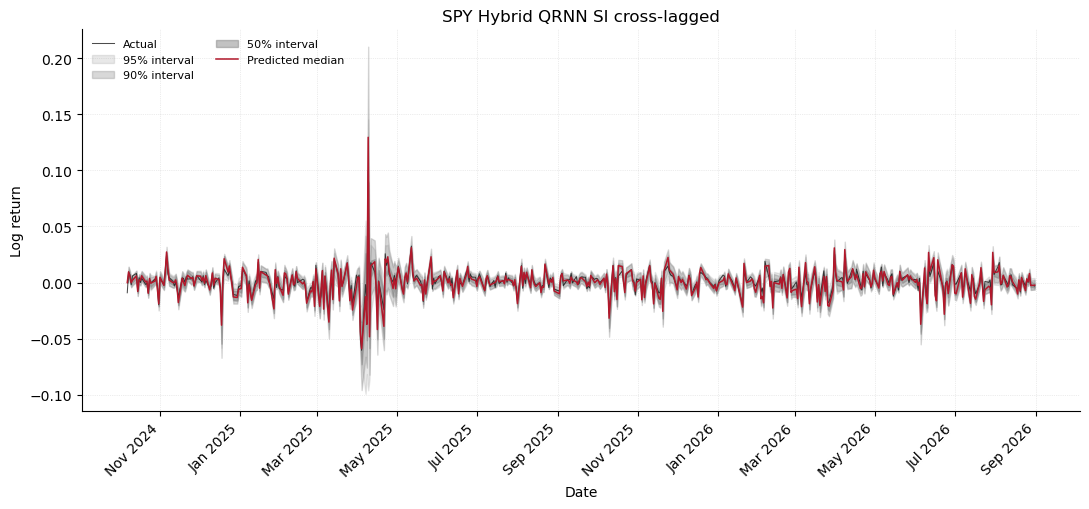


TEST METRICS — SPY HYBRID QRNN SI CROSS-LAGGED
 alpha       NLL  Hit_Rate      HRE    Sigma  Selected_Trial
 0.025 -3.549469  0.012605 0.012395 0.000376             162
 0.050 -3.688429  0.016807 0.033193 0.000467              84
 0.250 -3.992320  0.186975 0.063025 0.001285             124
 0.500 -4.179270  0.432773 0.067227 0.001399             145
 0.750 -4.122910  0.821429 0.071429 0.001460             151
 0.950 -3.846574  0.981092 0.031092 0.000483              47
 0.975 -3.720186  1.000000 0.025000 0.000291             197

Average NLL: -3.871308
Average HRE: 0.043337

CROSSOVER ANALYSIS — RAW TEST FORECASTS
 Lower_Alpha  Upper_Alpha  Violations  Violation_Rate  Tail_Pair
       0.025        0.050         193        0.405462       True
       0.050        0.250           0        0.000000      False
       0.250        0.500           1        0.002101      False
       0.500        0.750          34        0.071429      False
       0.750        0.950          14        0.02941

In [6]:
# ============================================================
# TEST EVALUATION AND PLOTTING — SPY HYBRID QRNN SI CROSS-LAGGED
# Loads saved checkpoints; does not retune any model
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


EVALUATION_MODEL_NAME = "spy_qrnn_si_cross"
EVALUATION_FORM = "SI"
EVALUATION_LAG = "cross"

EVALUATION_LEVELS = [
    0.025,
    0.050,
    0.250,
    0.500,
    0.750,
    0.950,
    0.975,
]

required_evaluation_objects = [
    "X_test",
    "y_test",
    "test_df",
    "device",
]

missing_evaluation_objects = [
    name
    for name in required_evaluation_objects
    if name not in globals()
]

if missing_evaluation_objects:
    raise RuntimeError(
        "Missing SPY preparation objects: "
        + ", ".join(missing_evaluation_objects)
        + "\nRun only the SPY data-preparation cell, then rerun this cell."
    )

EVALUATION_DIR = (
    Path("spy_original_tuning_results")
    / EVALUATION_MODEL_NAME
)

if not EVALUATION_DIR.exists():
    raise FileNotFoundError(
        f"Results directory not found: {EVALUATION_DIR.resolve()}"
    )


# ------------------------------------------------------------
# 1. Self-contained checkpoint-compatible model
# ------------------------------------------------------------

def evaluation_recurrence(
    y,
    X,
    beta1,
    beta2,
    beta3,
    fnn,
    psi,
):
    fnn_output = fnn(X).squeeze(-1)
    zero_value = y.new_zeros(())
    statistical_forecasts = [zero_value]
    hybrid_forecasts = [zero_value]

    for time_index in range(1, len(y)):
        previous_return = y[time_index - 1]

        if EVALUATION_LAG == "self":
            previous_state = statistical_forecasts[time_index - 1]
        else:
            previous_state = hybrid_forecasts[time_index - 1]

        if EVALUATION_FORM == "S":
            statistical_value = (
                beta1 * previous_state
                + beta2 * torch.abs(previous_return)
            )

        elif EVALUATION_FORM == "A":
            positive_return = torch.clamp(previous_return, min=0)
            negative_return = torch.clamp(-previous_return, min=0)
            statistical_value = (
                beta1 * previous_state
                + beta2 * positive_return
                + beta3 * negative_return
            )

        elif EVALUATION_FORM == "SI":
            absolute_return = torch.abs(previous_return)
            statistical_value = (
                beta1 * previous_state
                + beta2 * absolute_return
                + beta3 * previous_state * absolute_return
            )

        else:
            raise ValueError(f"Unknown form: {EVALUATION_FORM}")

        hybrid_value = (
            psi * statistical_value
            + (1.0 - psi) * fnn_output[time_index]
        )

        statistical_forecasts.append(statistical_value)
        hybrid_forecasts.append(hybrid_value)

    return (
        torch.stack(hybrid_forecasts),
        torch.stack(statistical_forecasts),
    )


class EvaluationHybridQRNN(nn.Module):
    def __init__(self, input_dim, config):
        super().__init__()

        self.eps = 1e-6
        self.beta1_raw = nn.Parameter(torch.tensor(1.386))
        self.beta2_raw = nn.Parameter(torch.tensor(0.3))

        if EVALUATION_FORM in {"A", "SI"}:
            self.beta3_raw = nn.Parameter(torch.tensor(0.3))
        else:
            self.beta3_raw = None

        self.psi_raw = nn.Parameter(torch.tensor(0.0))
        self.sigma_raw = nn.Parameter(torch.tensor(0.5))

        layers = []
        previous_dimension = input_dim

        for layer_index in range(config["n_hidden_layers"]):
            hidden_dimension = config[f"hidden_dim_{layer_index}"]
            layers.append(nn.Linear(previous_dimension, hidden_dimension))

            if config["layernorm"]:
                layers.append(nn.LayerNorm(hidden_dimension))

            activation = {
                "relu": nn.ReLU(),
                "elu": nn.ELU(),
                "gelu": nn.GELU(),
                "tanh": nn.Tanh(),
            }[config["activation"]]

            layers.append(activation)

            if config["dropout"] > 0:
                layers.append(nn.Dropout(config["dropout"]))

            previous_dimension = hidden_dimension

        layers.append(nn.Linear(previous_dimension, 1))
        self.fnn = nn.Sequential(*layers)

    def forward(self, y, X):
        beta1 = torch.sigmoid(self.beta1_raw)
        beta2 = F.softplus(self.beta2_raw)

        beta3 = (
            F.softplus(self.beta3_raw)
            if self.beta3_raw is not None
            else None
        )

        psi = torch.sigmoid(self.psi_raw)
        sigma = F.softplus(self.sigma_raw) + self.eps

        hybrid_forecast, statistical_forecast = evaluation_recurrence(
            y=y,
            X=X,
            beta1=beta1,
            beta2=beta2,
            beta3=beta3,
            fnn=self.fnn,
            psi=psi,
        )

        return hybrid_forecast, sigma, statistical_forecast


# ------------------------------------------------------------
# 2. Evaluation functions
# ------------------------------------------------------------

def evaluation_ald_nll(y, forecast, sigma, alpha):
    sigma = torch.clamp(
        sigma,
        min=torch.finfo(forecast.dtype).eps,
    )

    alpha_tensor = torch.as_tensor(
        alpha,
        dtype=forecast.dtype,
        device=forecast.device,
    )

    residual = y - forecast
    indicator = (residual < 0).to(forecast.dtype)
    check_loss = residual * (alpha_tensor - indicator)

    observation_nll = (
        -torch.log(alpha_tensor * (1.0 - alpha_tensor))
        + torch.log(sigma)
        + check_loss / sigma
    )

    return observation_nll


# ------------------------------------------------------------
# 3. Load each selected checkpoint and forecast the test sample
# ------------------------------------------------------------

test_forecast_columns = []
test_nll_columns = []
test_metric_records = []
loaded_test_models = {}

for alpha in EVALUATION_LEVELS:
    alpha_label = f"{alpha:.3f}"

    checkpoint_path = EVALUATION_DIR / (
        f"{EVALUATION_MODEL_NAME}_best_alpha_{alpha_label}.pt"
    )

    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f"Missing checkpoint: {checkpoint_path.resolve()}"
        )

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False,
    )

    model = EvaluationHybridQRNN(
        input_dim=X_test.shape[1],
        config=checkpoint["config"],
    ).to(device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    with torch.no_grad():
        forecast, sigma, _ = model(y_test, X_test)

        observation_nll = evaluation_ald_nll(
            y=y_test,
            forecast=forecast,
            sigma=sigma,
            alpha=alpha,
        )

    forecast_np = forecast.detach().cpu().numpy()
    nll_np = observation_nll.detach().cpu().numpy()
    y_test_np = y_test.detach().cpu().numpy()

    hit_rate = float(np.mean(y_test_np <= forecast_np))
    hre = abs(hit_rate - alpha)

    test_forecast_columns.append(forecast_np)
    test_nll_columns.append(nll_np)
    loaded_test_models[alpha] = model

    test_metric_records.append({
        "alpha": alpha,
        "NLL": float(np.mean(nll_np)),
        "Hit_Rate": hit_rate,
        "HRE": hre,
        "Sigma": float(sigma.detach().cpu().item()),
        "Selected_Trial": checkpoint["selected_trial"],
    })


test_forecast_matrix = np.column_stack(test_forecast_columns)
test_nll_matrix = np.column_stack(test_nll_columns)
test_metrics = pd.DataFrame(test_metric_records)


# ------------------------------------------------------------
# 4. Crossover diagnostics
# ------------------------------------------------------------

crossover_records = []
total_crossovers = 0
tail_crossovers = 0

for pair_index in range(len(EVALUATION_LEVELS) - 1):
    lower_level = EVALUATION_LEVELS[pair_index]
    upper_level = EVALUATION_LEVELS[pair_index + 1]

    violation_mask = (
        test_forecast_matrix[:, pair_index]
        > test_forecast_matrix[:, pair_index + 1]
    )

    violations = int(violation_mask.sum())
    violation_rate = violations / len(test_df)
    is_tail_pair = pair_index in {0, len(EVALUATION_LEVELS) - 2}

    total_crossovers += violations

    if is_tail_pair:
        tail_crossovers += violations

    crossover_records.append({
        "Lower_Alpha": lower_level,
        "Upper_Alpha": upper_level,
        "Violations": violations,
        "Violation_Rate": violation_rate,
        "Tail_Pair": is_tail_pair,
    })

crossover_table = pd.DataFrame(crossover_records)


# ------------------------------------------------------------
# 5. Save predictions, observation-level NLL and metrics
# ------------------------------------------------------------

predictions_table = pd.DataFrame({
    "Date": test_df.index,
    "Actual": y_test.detach().cpu().numpy(),
})

nll_table = pd.DataFrame({
    "Date": test_df.index,
})

for level_index, alpha in enumerate(EVALUATION_LEVELS):
    predictions_table[f"q_{alpha:.3f}"] = (
        test_forecast_matrix[:, level_index]
    )

    nll_table[f"nll_{alpha:.3f}"] = (
        test_nll_matrix[:, level_index]
    )

nll_table["average_nll_across_levels"] = (
    test_nll_matrix.mean(axis=1)
)

predictions_path = EVALUATION_DIR / (
    f"{EVALUATION_MODEL_NAME}_test_predictions.csv"
)

nll_path = EVALUATION_DIR / (
    f"{EVALUATION_MODEL_NAME}_test_nll_by_date.csv"
)

metrics_path = EVALUATION_DIR / (
    f"{EVALUATION_MODEL_NAME}_test_metrics.csv"
)

crossover_path = EVALUATION_DIR / (
    f"{EVALUATION_MODEL_NAME}_test_crossovers.csv"
)

predictions_table.to_csv(predictions_path, index=False)
nll_table.to_csv(nll_path, index=False)
test_metrics.to_csv(metrics_path, index=False)
crossover_table.to_csv(crossover_path, index=False)


# ------------------------------------------------------------
# 6. Test-period prediction plot
# Bitcoin-style presentation: black actual, red median,
# and grey 50%, 90%, and 95% interval bands
# ------------------------------------------------------------

dates = test_df.index
actual = y_test.detach().cpu().numpy()

fig, ax = plt.subplots(figsize=(11, 5.2))

ax.plot(
    dates,
    actual,
    color="black",
    linewidth=0.75,
    alpha=0.70,
    label="Actual",
)

ax.fill_between(
    dates,
    test_forecast_matrix[:, 0],
    test_forecast_matrix[:, 6],
    color="grey",
    alpha=0.18,
    label="95% interval",
)

ax.fill_between(
    dates,
    test_forecast_matrix[:, 1],
    test_forecast_matrix[:, 5],
    color="grey",
    alpha=0.30,
    label="90% interval",
)

ax.fill_between(
    dates,
    test_forecast_matrix[:, 2],
    test_forecast_matrix[:, 4],
    color="grey",
    alpha=0.48,
    label="50% interval",
)

ax.plot(
    dates,
    test_forecast_matrix[:, 3],
    color="#B2182B",
    linewidth=1.1,
    label="Predicted median",
)

ax.set(
    title=(
        f"SPY Hybrid QRNN {EVALUATION_FORM} "
        f"{EVALUATION_LAG}-lagged"
    ),
    xlabel="Date",
    ylabel="Log return",
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=2)
)

plt.setp(
    ax.xaxis.get_majorticklabels(),
    rotation=45,
    ha="right",
)

ax.grid(
    True,
    linestyle=":",
    linewidth=0.5,
    alpha=0.45,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    fontsize=8,
    ncol=2,
    loc="upper left",
)

fig.tight_layout()

plot_path = EVALUATION_DIR / (
    f"{EVALUATION_MODEL_NAME}_test_predictions.png"
)

fig.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------
# 7. Display concise results
# ------------------------------------------------------------

print("\n" + "=" * 72)
print(
    "TEST METRICS — SPY HYBRID QRNN "
    "SI CROSS-LAGGED"
)
print("=" * 72)
print(test_metrics.to_string(index=False))

print("\nAverage NLL:", f"{test_metrics['NLL'].mean():.6f}")
print("Average HRE:", f"{test_metrics['HRE'].mean():.6f}")

print("\n" + "=" * 72)
print("CROSSOVER ANALYSIS — RAW TEST FORECASTS")
print("=" * 72)
print(crossover_table.to_string(index=False))

print("\nTotal crossover violations:", total_crossovers)
print("Tail crossover violations:", tail_crossovers)

print("\nSaved outputs:")
print("Predictions:", predictions_path)
print("Observation-level NLL:", nll_path)
print("Metrics:", metrics_path)
print("Crossovers:", crossover_path)
print("Plot:", plot_path)


## Crossover - Sorting


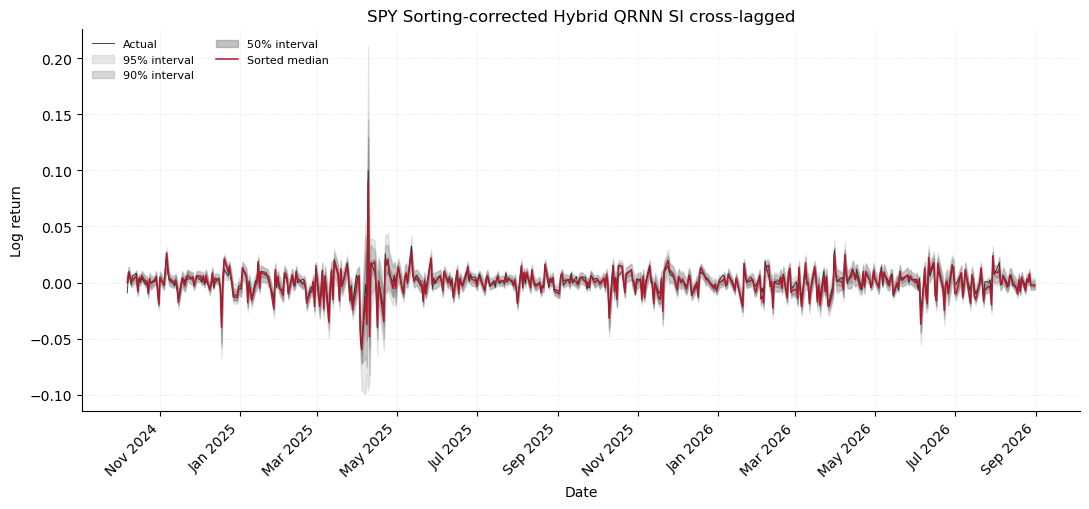

TEST METRICS — SORTING SPY QRNN SI CROSS-LAGGED
     alpha  raw_test_nll  sorted_test_nll  raw_hit_rate  sorted_hit_rate    raw_hre  sorted_hre  mean_absolute_adjustment
0.02500000   -3.54946865      -3.51965314    0.01260504       0.00630252 0.01239496  0.01869748                0.00104451
0.05000000   -3.68842938      -3.77027504    0.01680672       0.02100840 0.03319328  0.02899160                0.00084776
0.25000000   -3.99232045      -4.01897157    0.18697479       0.18907563 0.06302521  0.06092437                0.00018097
0.50000000   -4.17927030      -4.20762015    0.43277311       0.42226891 0.06722689  0.07773109                0.00023137
0.75000000   -4.12291050      -4.14593203    0.82142857       0.83193277 0.07142857  0.08193277                0.00026711
0.95000000   -3.84657375      -3.90368545    0.98109244       0.98109244 0.03109244  0.03109244                0.00057834
0.97500000   -3.72018684      -3.67519123    1.00000000       1.00000000 0.02500000  0.02500000   

In [9]:
# ============================================================
# CROSSOVER METHOD: POST-PROCESSING SORTING
# SPY HYBRID QRNN SI — CROSS-LAGGED
# Uses saved unrestricted forecasts; no retuning is required
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# ------------------------------------------------------------
# 1. Settings and saved original results
# ------------------------------------------------------------

SORTING_LEVELS = np.array([
    0.025,
    0.050,
    0.250,
    0.500,
    0.750,
    0.950,
    0.975,
], dtype=float)

ORIGINAL_MODEL_NAME = "spy_qrnn_si_cross"

ORIGINAL_RESULT_DIR = (
    Path("spy_original_tuning_results")
    / ORIGINAL_MODEL_NAME
)

SORTING_OUTPUT_DIR = (
    Path("spy_sorting_crossover_results")
    / ORIGINAL_MODEL_NAME
)
SORTING_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

predictions_path = ORIGINAL_RESULT_DIR / (
    f"{ORIGINAL_MODEL_NAME}_test_predictions.csv"
)
metrics_path = ORIGINAL_RESULT_DIR / (
    f"{ORIGINAL_MODEL_NAME}_test_metrics.csv"
)

if not predictions_path.exists():
    raise FileNotFoundError(
        f"Original prediction file not found: {predictions_path.resolve()}\n"
        "Run the original test-evaluation cell first; do not rerun tuning."
    )

if not metrics_path.exists():
    raise FileNotFoundError(
        f"Original metric file not found: {metrics_path.resolve()}\n"
        "Run the original test-evaluation cell first; do not rerun tuning."
    )


# ------------------------------------------------------------
# 2. Load unrestricted forecasts and sort each date independently
# ------------------------------------------------------------

raw_table = pd.read_csv(predictions_path, parse_dates=["Date"])
original_metrics = pd.read_csv(metrics_path)

quantile_columns = [f"q_{alpha:.3f}" for alpha in SORTING_LEVELS]
missing_columns = [
    column for column in ["Date", "Actual", *quantile_columns]
    if column not in raw_table.columns
]

if missing_columns:
    raise ValueError(
        "Missing columns in saved prediction file: "
        + ", ".join(missing_columns)
    )

raw_forecasts = raw_table[quantile_columns].to_numpy(dtype=float)
sorted_forecasts = np.sort(raw_forecasts, axis=1)
actual = raw_table["Actual"].to_numpy(dtype=float)
dates = pd.to_datetime(raw_table["Date"])

if len(original_metrics) != len(SORTING_LEVELS):
    raise ValueError("The saved metric file must contain all seven levels.")

sigma_by_level = (
    original_metrics
    .assign(alpha=original_metrics["alpha"].astype(float))
    .set_index("alpha")["Sigma"]
)


# ------------------------------------------------------------
# 3. Recalculate ALD NLL, coverage and HRE after sorting
# ------------------------------------------------------------

def ald_nll_by_observation(y, forecast, sigma, alpha):
    sigma = max(float(sigma), np.finfo(float).eps)
    residual = y - forecast
    indicator = (residual < 0.0).astype(float)
    check_loss = residual * (float(alpha) - indicator)

    return (
        -np.log(float(alpha) * (1.0 - float(alpha)))
        + np.log(sigma)
        + check_loss / sigma
    )


metric_records = []
raw_nll_columns = []
sorted_nll_columns = []

for level_index, alpha in enumerate(SORTING_LEVELS):
    sigma = float(sigma_by_level.loc[alpha])
    raw_forecast = raw_forecasts[:, level_index]
    sorted_forecast = sorted_forecasts[:, level_index]

    raw_nll = ald_nll_by_observation(
        actual, raw_forecast, sigma, alpha
    )
    sorted_nll = ald_nll_by_observation(
        actual, sorted_forecast, sigma, alpha
    )

    raw_hit_rate = float(np.mean(actual <= raw_forecast))
    sorted_hit_rate = float(np.mean(actual <= sorted_forecast))

    raw_nll_columns.append(raw_nll)
    sorted_nll_columns.append(sorted_nll)

    metric_records.append({
        "alpha": alpha,
        "raw_test_nll": float(np.mean(raw_nll)),
        "sorted_test_nll": float(np.mean(sorted_nll)),
        "raw_hit_rate": raw_hit_rate,
        "sorted_hit_rate": sorted_hit_rate,
        "raw_hre": abs(raw_hit_rate - alpha),
        "sorted_hre": abs(sorted_hit_rate - alpha),
        "mean_absolute_adjustment": float(
            np.mean(np.abs(sorted_forecast - raw_forecast))
        ),
    })

sorting_metrics = pd.DataFrame(metric_records)
raw_nll_matrix = np.column_stack(raw_nll_columns)
sorted_nll_matrix = np.column_stack(sorted_nll_columns)


# ------------------------------------------------------------
# 4. Crossover and adjustment diagnostics
# ------------------------------------------------------------

def crossover_summary(forecast_matrix):
    pair_records = []
    total = 0
    tail = 0

    for pair_index in range(len(SORTING_LEVELS) - 1):
        violation_mask = (
            forecast_matrix[:, pair_index]
            > forecast_matrix[:, pair_index + 1]
        )
        count = int(violation_mask.sum())
        is_tail = pair_index in {0, len(SORTING_LEVELS) - 2}
        total += count
        if is_tail:
            tail += count

        pair_records.append({
            "lower_alpha": SORTING_LEVELS[pair_index],
            "upper_alpha": SORTING_LEVELS[pair_index + 1],
            "violations": count,
            "violation_rate": count / len(forecast_matrix),
            "tail_pair": is_tail,
        })

    return total, tail, pd.DataFrame(pair_records)


raw_crossover, raw_tail, raw_pair_table = crossover_summary(
    raw_forecasts
)
sorted_crossover, sorted_tail, sorted_pair_table = crossover_summary(
    sorted_forecasts
)

adjustment_matrix = sorted_forecasts - raw_forecasts
changed_rows = np.any(
    ~np.isclose(adjustment_matrix, 0.0, atol=1e-12),
    axis=1,
)


# ------------------------------------------------------------
# 5. Save all sorting results
# ------------------------------------------------------------

sorted_prediction_table = pd.DataFrame({
    "Date": dates,
    "Actual": actual,
})

for level_index, alpha in enumerate(SORTING_LEVELS):
    sorted_prediction_table[f"raw_q_{alpha:.3f}"] = (
        raw_forecasts[:, level_index]
    )
    sorted_prediction_table[f"sorted_q_{alpha:.3f}"] = (
        sorted_forecasts[:, level_index]
    )

sorting_nll_by_date = pd.DataFrame({"Date": dates})
for level_index, alpha in enumerate(SORTING_LEVELS):
    sorting_nll_by_date[f"raw_nll_{alpha:.3f}"] = (
        raw_nll_matrix[:, level_index]
    )
    sorting_nll_by_date[f"sorted_nll_{alpha:.3f}"] = (
        sorted_nll_matrix[:, level_index]
    )
sorting_nll_by_date["raw_average_nll"] = raw_nll_matrix.mean(axis=1)
sorting_nll_by_date["sorted_average_nll"] = (
    sorted_nll_matrix.mean(axis=1)
)

sorting_summary = pd.DataFrame([{
    "model": ORIGINAL_MODEL_NAME,
    "test_T": len(actual),
    "raw_average_nll": sorting_metrics["raw_test_nll"].mean(),
    "sorted_average_nll": sorting_metrics["sorted_test_nll"].mean(),
    "raw_average_hre": sorting_metrics["raw_hre"].mean(),
    "sorted_average_hre": sorting_metrics["sorted_hre"].mean(),
    "raw_crossover": raw_crossover,
    "sorted_crossover": sorted_crossover,
    "raw_tail": raw_tail,
    "sorted_tail": sorted_tail,
    "changed_observations": int(changed_rows.sum()),
    "mean_absolute_adjustment": float(
        np.mean(np.abs(adjustment_matrix))
    ),
    "maximum_absolute_adjustment": float(
        np.max(np.abs(adjustment_matrix))
    ),
}])

sorted_prediction_table.to_csv(
    SORTING_OUTPUT_DIR / f"sorting_{ORIGINAL_MODEL_NAME}_predictions.csv",
    index=False,
)
sorting_metrics.to_csv(
    SORTING_OUTPUT_DIR / f"sorting_{ORIGINAL_MODEL_NAME}_metrics.csv",
    index=False,
)
sorting_nll_by_date.to_csv(
    SORTING_OUTPUT_DIR / f"sorting_{ORIGINAL_MODEL_NAME}_nll_by_date.csv",
    index=False,
)
raw_pair_table.to_csv(
    SORTING_OUTPUT_DIR / f"sorting_{ORIGINAL_MODEL_NAME}_raw_crossovers.csv",
    index=False,
)
sorted_pair_table.to_csv(
    SORTING_OUTPUT_DIR / f"sorting_{ORIGINAL_MODEL_NAME}_crossovers.csv",
    index=False,
)
sorting_summary.to_csv(
    SORTING_OUTPUT_DIR / f"sorting_{ORIGINAL_MODEL_NAME}_summary.csv",
    index=False,
)


# ------------------------------------------------------------
# 6. Bitcoin-style plot: black actual, red median, grey bands
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 5.2))

ax.plot(
    dates,
    actual,
    color="black",
    linewidth=0.75,
    alpha=0.70,
    label="Actual",
)

ax.fill_between(
    dates,
    sorted_forecasts[:, 0],
    sorted_forecasts[:, 6],
    color="grey",
    alpha=0.18,
    label="95% interval",
)

ax.fill_between(
    dates,
    sorted_forecasts[:, 1],
    sorted_forecasts[:, 5],
    color="grey",
    alpha=0.30,
    label="90% interval",
)

ax.fill_between(
    dates,
    sorted_forecasts[:, 2],
    sorted_forecasts[:, 4],
    color="grey",
    alpha=0.48,
    label="50% interval",
)

ax.plot(
    dates,
    sorted_forecasts[:, 3],
    color="#B2182B",
    linewidth=1.1,
    label="Sorted median",
)

ax.set(
    title="SPY Sorting-corrected Hybrid QRNN SI cross-lagged",
    xlabel="Date",
    ylabel="Log return",
)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

plt.setp(
    ax.xaxis.get_majorticklabels(),
    rotation=45,
    ha="right",
)

ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.45)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, fontsize=8, ncol=2, loc="upper left")

fig.tight_layout()

plot_path = SORTING_OUTPUT_DIR / (
    f"sorting_{ORIGINAL_MODEL_NAME}_predictions.png"
)
fig.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# 7. Report
# ------------------------------------------------------------

print("=" * 79)
print("TEST METRICS — SORTING SPY QRNN SI CROSS-LAGGED")
print("=" * 79)
print(sorting_metrics.to_string(index=False, float_format=lambda x: f"{x:.8f}"))

print("\n" + "=" * 79)
print("SUMMARY")
print("=" * 79)
print(f"Raw average NLL:         {sorting_summary.loc[0, 'raw_average_nll']:.6f}")
print(f"Sorted average NLL:      {sorting_summary.loc[0, 'sorted_average_nll']:.6f}")
print(f"Raw average HRE:         {sorting_summary.loc[0, 'raw_average_hre']:.6f}")
print(f"Sorted average HRE:      {sorting_summary.loc[0, 'sorted_average_hre']:.6f}")
print(f"Raw crossover:           {raw_crossover}")
print(f"Sorted crossover:        {sorted_crossover}")
print(f"Raw tail violations:     {raw_tail}")
print(f"Sorted tail violations:  {sorted_tail}")
print(f"Changed observations:    {int(changed_rows.sum())}/{len(actual)}")
print(
    "Mean adjustment:         "
    f"{np.mean(np.abs(adjustment_matrix)):.8f}"
)
print(
    "Maximum adjustment:      "
    f"{np.max(np.abs(adjustment_matrix)):.8f}"
)
print(f"\nPlot saved to:\n{plot_path}")
print(f"\nAll sorting results saved under:\n{SORTING_OUTPUT_DIR}")


## Crossover - PAVA


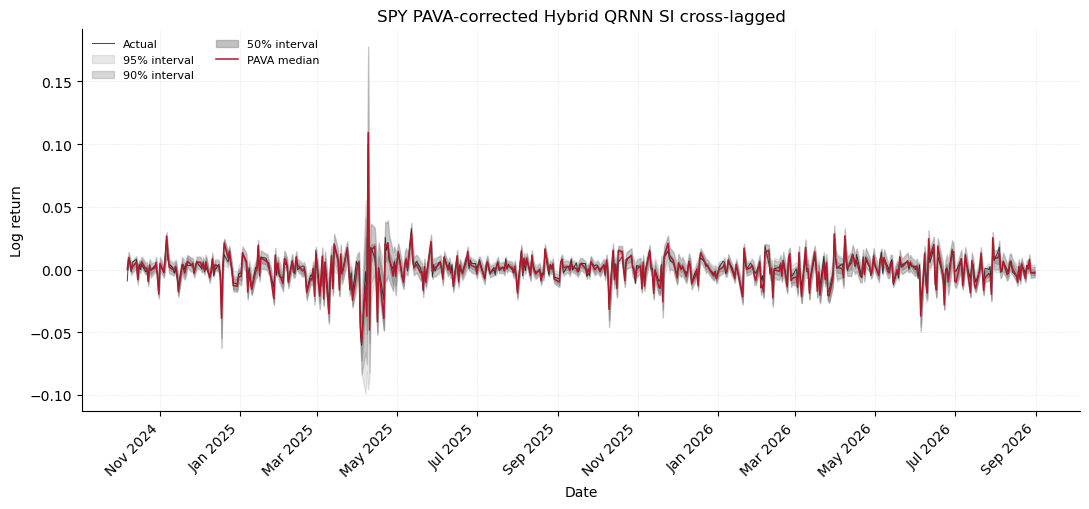

TEST METRICS — EQUAL-WEIGHT PAVA SPY QRNN SI CROSS-LAGGED
     alpha     raw_nll    pava_nll  raw_pinball  pava_pinball  raw_hit_rate  pava_hit_rate    raw_hre   pava_hre  mean_absolute_adjustment
0.02500000 -3.54946865 -3.55125767   0.00023410    0.00023343    0.01260504     0.00840336 0.01239496 0.01659664                0.00052526
0.05000000 -3.68842938 -3.74166684   0.00043606    0.00041121    0.01680672     0.01890756 0.03319328 0.03109244                0.00051926
0.25000000 -3.99232045 -3.99399571   0.00127305    0.00127090    0.18697479     0.18697479 0.06302521 0.06302521                0.00000687
0.50000000 -4.17927030 -4.20164847   0.00140800    0.00137669    0.43277311     0.42857143 0.06722689 0.07142857                0.00010692
0.75000000 -4.12291050 -4.14591850   0.00106937    0.00103578    0.82142857     0.82773109 0.07142857 0.07773109                0.00013389
0.95000000 -3.84657375 -3.87521342   0.00035836    0.00034453    0.98109244     0.98109244 0.03109244 0.0310

In [12]:
# ============================================================
# CROSSOVER METHOD: EQUAL-WEIGHT PAVA
# SPY HYBRID QRNN SI — CROSS-LAGGED
# Uses saved unrestricted forecasts; no retuning is required
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# ------------------------------------------------------------
# 1. Settings and saved original results
# ------------------------------------------------------------

PAVA_LEVELS = np.array([
    0.025,
    0.050,
    0.250,
    0.500,
    0.750,
    0.950,
    0.975,
], dtype=float)

ORIGINAL_MODEL_NAME = "spy_qrnn_si_cross"

ORIGINAL_RESULT_DIR = (
    Path("spy_original_tuning_results")
    / ORIGINAL_MODEL_NAME
)

PAVA_OUTPUT_DIR = (
    Path("spy_pava_crossover_results")
    / ORIGINAL_MODEL_NAME
)
PAVA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

predictions_path = ORIGINAL_RESULT_DIR / (
    f"{ORIGINAL_MODEL_NAME}_test_predictions.csv"
)
metrics_path = ORIGINAL_RESULT_DIR / (
    f"{ORIGINAL_MODEL_NAME}_test_metrics.csv"
)

if not predictions_path.exists():
    raise FileNotFoundError(
        f"Original prediction file not found: {predictions_path.resolve()}\n"
        "Run the original test-evaluation cell first; do not rerun tuning."
    )

if not metrics_path.exists():
    raise FileNotFoundError(
        f"Original metric file not found: {metrics_path.resolve()}\n"
        "Run the original test-evaluation cell first; do not rerun tuning."
    )


# ------------------------------------------------------------
# 2. Equal-weight PAVA
# ------------------------------------------------------------

def equal_weight_pava(values):
    """Least-squares projection onto a nondecreasing sequence."""
    values = np.asarray(values, dtype=float)

    block_values = []
    block_weights = []
    block_starts = []
    block_ends = []

    for index, value in enumerate(values):
        block_values.append(float(value))
        block_weights.append(1.0)
        block_starts.append(index)
        block_ends.append(index)

        while (
            len(block_values) >= 2
            and block_values[-2] > block_values[-1]
        ):
            merged_weight = block_weights[-2] + block_weights[-1]
            merged_value = (
                block_weights[-2] * block_values[-2]
                + block_weights[-1] * block_values[-1]
            ) / merged_weight
            merged_start = block_starts[-2]
            merged_end = block_ends[-1]

            block_values[-2:] = [merged_value]
            block_weights[-2:] = [merged_weight]
            block_starts[-2:] = [merged_start]
            block_ends[-2:] = [merged_end]

    projected = np.empty_like(values, dtype=float)
    for value, start, end in zip(
        block_values,
        block_starts,
        block_ends,
    ):
        projected[start:end + 1] = value

    return projected


# ------------------------------------------------------------
# 3. Load unrestricted forecasts and project every test date
# ------------------------------------------------------------

raw_table = pd.read_csv(predictions_path, parse_dates=["Date"])
original_metrics = pd.read_csv(metrics_path)

quantile_columns = [f"q_{alpha:.3f}" for alpha in PAVA_LEVELS]
missing_columns = [
    column for column in ["Date", "Actual", *quantile_columns]
    if column not in raw_table.columns
]

if missing_columns:
    raise ValueError(
        "Missing columns in saved prediction file: "
        + ", ".join(missing_columns)
    )

raw_forecasts = raw_table[quantile_columns].to_numpy(dtype=float)
pava_forecasts = np.vstack([
    equal_weight_pava(row)
    for row in raw_forecasts
])

actual = raw_table["Actual"].to_numpy(dtype=float)
dates = pd.to_datetime(raw_table["Date"])

if len(original_metrics) != len(PAVA_LEVELS):
    raise ValueError("The saved metric file must contain all seven levels.")

sigma_by_level = (
    original_metrics
    .assign(alpha=original_metrics["alpha"].astype(float))
    .set_index("alpha")["Sigma"]
)


# ------------------------------------------------------------
# 4. Recalculate ALD NLL, pinball loss, coverage and HRE
# ------------------------------------------------------------

def pinball_by_observation(y, forecast, alpha):
    residual = y - forecast
    indicator = (residual < 0.0).astype(float)
    return residual * (float(alpha) - indicator)


def ald_nll_by_observation(y, forecast, sigma, alpha):
    sigma = max(float(sigma), np.finfo(float).eps)
    return (
        -np.log(float(alpha) * (1.0 - float(alpha)))
        + np.log(sigma)
        + pinball_by_observation(y, forecast, alpha) / sigma
    )


metric_records = []
raw_nll_columns = []
pava_nll_columns = []

for level_index, alpha in enumerate(PAVA_LEVELS):
    sigma = float(sigma_by_level.loc[alpha])
    raw_forecast = raw_forecasts[:, level_index]
    pava_forecast = pava_forecasts[:, level_index]

    raw_pinball = pinball_by_observation(actual, raw_forecast, alpha)
    pava_pinball = pinball_by_observation(actual, pava_forecast, alpha)
    raw_nll = ald_nll_by_observation(
        actual, raw_forecast, sigma, alpha
    )
    pava_nll = ald_nll_by_observation(
        actual, pava_forecast, sigma, alpha
    )

    raw_hit_rate = float(np.mean(actual <= raw_forecast))
    pava_hit_rate = float(np.mean(actual <= pava_forecast))

    raw_nll_columns.append(raw_nll)
    pava_nll_columns.append(pava_nll)

    metric_records.append({
        "alpha": alpha,
        "raw_nll": float(np.mean(raw_nll)),
        "pava_nll": float(np.mean(pava_nll)),
        "raw_pinball": float(np.mean(raw_pinball)),
        "pava_pinball": float(np.mean(pava_pinball)),
        "raw_hit_rate": raw_hit_rate,
        "pava_hit_rate": pava_hit_rate,
        "raw_hre": abs(raw_hit_rate - alpha),
        "pava_hre": abs(pava_hit_rate - alpha),
        "mean_absolute_adjustment": float(
            np.mean(np.abs(pava_forecast - raw_forecast))
        ),
    })

pava_metrics = pd.DataFrame(metric_records)
raw_nll_matrix = np.column_stack(raw_nll_columns)
pava_nll_matrix = np.column_stack(pava_nll_columns)


# ------------------------------------------------------------
# 5. Crossover and adjustment diagnostics
# ------------------------------------------------------------

def crossover_summary(forecast_matrix):
    pair_records = []
    total = 0
    tail = 0

    for pair_index in range(len(PAVA_LEVELS) - 1):
        violation_mask = (
            forecast_matrix[:, pair_index]
            > forecast_matrix[:, pair_index + 1]
        )
        count = int(violation_mask.sum())
        is_tail = pair_index in {0, len(PAVA_LEVELS) - 2}
        total += count
        if is_tail:
            tail += count

        pair_records.append({
            "lower_alpha": PAVA_LEVELS[pair_index],
            "upper_alpha": PAVA_LEVELS[pair_index + 1],
            "violations": count,
            "violation_rate": count / len(forecast_matrix),
            "tail_pair": is_tail,
        })

    return total, tail, pd.DataFrame(pair_records)


raw_crossover, raw_tail, raw_pair_table = crossover_summary(
    raw_forecasts
)
pava_crossover, pava_tail, pava_pair_table = crossover_summary(
    pava_forecasts
)

adjustment_matrix = pava_forecasts - raw_forecasts
changed_rows = np.any(
    ~np.isclose(adjustment_matrix, 0.0, atol=1e-12),
    axis=1,
)


# ------------------------------------------------------------
# 6. Save all PAVA results
# ------------------------------------------------------------

pava_prediction_table = pd.DataFrame({
    "Date": dates,
    "Actual": actual,
})

for level_index, alpha in enumerate(PAVA_LEVELS):
    pava_prediction_table[f"raw_q_{alpha:.3f}"] = (
        raw_forecasts[:, level_index]
    )
    pava_prediction_table[f"pava_q_{alpha:.3f}"] = (
        pava_forecasts[:, level_index]
    )

pava_nll_by_date = pd.DataFrame({"Date": dates})
for level_index, alpha in enumerate(PAVA_LEVELS):
    pava_nll_by_date[f"raw_nll_{alpha:.3f}"] = (
        raw_nll_matrix[:, level_index]
    )
    pava_nll_by_date[f"pava_nll_{alpha:.3f}"] = (
        pava_nll_matrix[:, level_index]
    )
pava_nll_by_date["raw_average_nll"] = raw_nll_matrix.mean(axis=1)
pava_nll_by_date["pava_average_nll"] = pava_nll_matrix.mean(axis=1)

pava_summary = pd.DataFrame([{
    "model": ORIGINAL_MODEL_NAME,
    "test_T": len(actual),
    "raw_average_nll": pava_metrics["raw_nll"].mean(),
    "pava_average_nll": pava_metrics["pava_nll"].mean(),
    "raw_average_hre": pava_metrics["raw_hre"].mean(),
    "pava_average_hre": pava_metrics["pava_hre"].mean(),
    "raw_total_pinball": pava_metrics["raw_pinball"].sum(),
    "pava_total_pinball": pava_metrics["pava_pinball"].sum(),
    "raw_crossover": raw_crossover,
    "pava_crossover": pava_crossover,
    "raw_tail": raw_tail,
    "pava_tail": pava_tail,
    "changed_observations": int(changed_rows.sum()),
    "mean_absolute_adjustment": float(
        np.mean(np.abs(adjustment_matrix))
    ),
    "maximum_absolute_adjustment": float(
        np.max(np.abs(adjustment_matrix))
    ),
}])

pava_prediction_table.to_csv(
    PAVA_OUTPUT_DIR / f"pava_{ORIGINAL_MODEL_NAME}_predictions.csv",
    index=False,
)
pava_metrics.to_csv(
    PAVA_OUTPUT_DIR / f"pava_{ORIGINAL_MODEL_NAME}_metrics.csv",
    index=False,
)
pava_nll_by_date.to_csv(
    PAVA_OUTPUT_DIR / f"pava_{ORIGINAL_MODEL_NAME}_nll_by_date.csv",
    index=False,
)
raw_pair_table.to_csv(
    PAVA_OUTPUT_DIR / f"pava_{ORIGINAL_MODEL_NAME}_raw_crossovers.csv",
    index=False,
)
pava_pair_table.to_csv(
    PAVA_OUTPUT_DIR / f"pava_{ORIGINAL_MODEL_NAME}_crossovers.csv",
    index=False,
)
pava_summary.to_csv(
    PAVA_OUTPUT_DIR / f"pava_{ORIGINAL_MODEL_NAME}_summary.csv",
    index=False,
)


# ------------------------------------------------------------
# 7. Bitcoin-style plot: black actual, red median, grey bands
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 5.2))

ax.plot(
    dates,
    actual,
    color="black",
    linewidth=0.75,
    alpha=0.70,
    label="Actual",
)

ax.fill_between(
    dates,
    pava_forecasts[:, 0],
    pava_forecasts[:, 6],
    color="grey",
    alpha=0.18,
    label="95% interval",
)

ax.fill_between(
    dates,
    pava_forecasts[:, 1],
    pava_forecasts[:, 5],
    color="grey",
    alpha=0.30,
    label="90% interval",
)

ax.fill_between(
    dates,
    pava_forecasts[:, 2],
    pava_forecasts[:, 4],
    color="grey",
    alpha=0.48,
    label="50% interval",
)

ax.plot(
    dates,
    pava_forecasts[:, 3],
    color="#B2182B",
    linewidth=1.1,
    label="PAVA median",
)

ax.set(
    title="SPY PAVA-corrected Hybrid QRNN SI cross-lagged",
    xlabel="Date",
    ylabel="Log return",
)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

plt.setp(
    ax.xaxis.get_majorticklabels(),
    rotation=45,
    ha="right",
)

ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.45)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, fontsize=8, ncol=2, loc="upper left")

fig.tight_layout()

plot_path = PAVA_OUTPUT_DIR / (
    f"pava_{ORIGINAL_MODEL_NAME}_predictions.png"
)
fig.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# 8. Report
# ------------------------------------------------------------

print("=" * 79)
print("TEST METRICS — EQUAL-WEIGHT PAVA SPY QRNN SI CROSS-LAGGED")
print("=" * 79)
print(pava_metrics.to_string(index=False, float_format=lambda x: f"{x:.8f}"))

print("\n" + "=" * 79)
print("SUMMARY")
print("=" * 79)
print(f"Raw average NLL:       {pava_summary.loc[0, 'raw_average_nll']:.6f}")
print(f"PAVA average NLL:      {pava_summary.loc[0, 'pava_average_nll']:.6f}")
print(f"Raw average HRE:       {pava_summary.loc[0, 'raw_average_hre']:.6f}")
print(f"PAVA average HRE:      {pava_summary.loc[0, 'pava_average_hre']:.6f}")
print(f"Raw total pinball:     {pava_summary.loc[0, 'raw_total_pinball']:.8f}")
print(f"PAVA total pinball:    {pava_summary.loc[0, 'pava_total_pinball']:.8f}")
print(f"Raw crossover:         {raw_crossover}")
print(f"PAVA crossover:        {pava_crossover}")
print(f"Raw tail violations:   {raw_tail}")
print(f"PAVA tail violations:  {pava_tail}")
print(f"Changed observations:  {int(changed_rows.sum())}/{len(actual)}")
print(
    "Mean adjustment:       "
    f"{np.mean(np.abs(adjustment_matrix)):.8f}"
)
print(
    "Maximum adjustment:    "
    f"{np.max(np.abs(adjustment_matrix)):.8f}"
)
print(f"\nPlot saved to:\n{plot_path}")
print(f"\nAll PAVA results saved under:\n{PAVA_OUTPUT_DIR}")


## Crossover - Method 1b


In [15]:
import copy
from pathlib import Path

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from optuna.samplers import TPESampler


# ============================================================
# METHOD 1B -- JOINT QRNN S Self-LAGGED
# Complete-output non-crossing through positive adjacent spacing
# ============================================================

M1B_DISTRIBUTION = 'qrnn'   # 'qrnn' or 'ernn'
M1B_FORM = 'si'           # 's', 'a', or 'si'
M1B_LAG = 'cross'             # 'self' or 'cross'
M1B_N_TRIALS = 800
M1B_MAX_EPOCHS = 800
M1B_BASE_SEED = 2026

m1b_levels = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
m1b_spacing_names = [
    'delta12', 'delta23', 'delta34',
    'delta45', 'delta56', 'delta67',
]
m1b_model_tag = (
    f'spy_method1b_joint_{M1B_DISTRIBUTION}_{M1B_FORM}_{M1B_LAG}'
)
M1B_OUTPUT_DIR = Path('spy_method1b_results') / m1b_model_tag
M1B_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def m1b_validate_inputs():
    required = ('y_train', 'X_train', 'y_val', 'X_val')
    missing = [name for name in required if name not in globals()]
    if missing:
        raise NameError(
            'Run the notebook data preparation first. Missing: '
            + ', '.join(missing)
        )

    for y_name, x_name in (
        ('y_train', 'X_train'),
        ('y_val', 'X_val'),
    ):
        y_value = globals()[y_name]
        x_value = globals()[x_name]
        if not isinstance(y_value, torch.Tensor) or not isinstance(
            x_value, torch.Tensor
        ):
            raise TypeError(f'{y_name} and {x_name} must be tensors.')
        if y_value.ndim != 1 or x_value.ndim != 2:
            raise ValueError(f'{y_name} must be (T,) and {x_name} (T,p).')
        if len(y_value) != len(x_value):
            raise ValueError(f'{y_name} and {x_name} lengths differ.')


class Method1BJointHybrid(nn.Module):
    """Central hybrid forecast plus six jointly learned positive gaps."""

    def __init__(self, input_dim, config):
        super().__init__()
        self.eps = 1e-6

        # Identifiable statistical/mixing parameters for the median only.
        self.persistence_raw = nn.Parameter(torch.tensor(1.386))
        self.news1_raw = nn.Parameter(torch.tensor(0.3))
        if M1B_FORM in ('a', 'si'):
            self.news2_raw = nn.Parameter(torch.tensor(0.3))
        self.psi_raw = nn.Parameter(torch.tensor(0.0))

        # One loss scale per final level.
        self.sigma_raw = nn.Parameter(torch.full((7,), 0.5))

        layers = []
        previous_dim = input_dim
        for index in range(config['n_hidden_layers']):
            hidden_dim = config[f'hidden_dim_{index}']
            layers.append(nn.Linear(previous_dim, hidden_dim))
            if config['layernorm']:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(self._activation(config['activation']))
            if config['dropout'] > 0:
                layers.append(nn.Dropout(config['dropout']))
            previous_dim = hidden_dim

        self.feature_extractor = nn.Sequential(*layers)
        self.median_head = nn.Linear(previous_dim, 1)
        self.spacing_heads = nn.ModuleDict({
            name: nn.Linear(previous_dim + 1, 1)
            for name in m1b_spacing_names
        })

        for module in self.modules():
            if isinstance(module, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(module.weight)
                else:
                    nn.init.kaiming_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    @staticmethod
    def _activation(name):
        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh(),
        }[name]

    def _positive_spacing(self, features, reference, name):
        spacing_input = torch.cat(
            [features, reference.unsqueeze(1)], dim=1
        )
        raw_spacing = self.spacing_heads[name](spacing_input).squeeze(1)
        return F.softplus(raw_spacing) + self.eps

    def _median_recursion(
        self,
        y,
        median_fnn,
        initial_state=None,
        initial_y=None,
    ):
        if (initial_state is None) != (initial_y is None):
            raise ValueError(
                'initial_state and initial_y must be supplied together.'
            )

        persistence = torch.sigmoid(self.persistence_raw)
        news1 = F.softplus(self.news1_raw)
        news2 = (
            F.softplus(self.news2_raw)
            if M1B_FORM in ('a', 'si')
            else None
        )
        psi = torch.sigmoid(self.psi_raw)

        has_state = initial_state is not None
        previous_state = (
            initial_state if has_state else y.new_zeros(())
        )

        statistical_values = []
        hybrid_values = []

        for time_index in range(len(y)):
            if time_index == 0 and not has_state:
                zero = y.new_zeros(())
                statistical_values.append(zero)
                hybrid_values.append(zero)
                continue

            previous_y = (
                initial_y if time_index == 0 else y[time_index - 1]
            )
            if M1B_FORM == 'a':
                positive_return = torch.clamp(previous_y, min=0)
                negative_return = torch.clamp(-previous_y, min=0)
                statistical = (
                    persistence * previous_state
                    + news1 * positive_return
                    + news2 * negative_return
                )
            else:
                absolute_return = torch.abs(previous_y)
                statistical = (
                    persistence * previous_state
                    + news1 * absolute_return
                )
                if M1B_FORM == 'si':
                    statistical = (
                        statistical
                        + news2 * previous_state * absolute_return
                    )

            hybrid = psi * statistical + (1 - psi) * median_fnn[
                time_index
            ]
            statistical_values.append(statistical)
            hybrid_values.append(hybrid)

            previous_state = (
                statistical if M1B_LAG == 'self' else hybrid
            )

        return (
            torch.stack(hybrid_values),
            torch.stack(statistical_values),
        )

    def forward(
        self,
        y,
        X,
        initial_state=None,
        initial_y=None,
    ):
        features = self.feature_extractor(X)
        median_fnn = self.median_head(features).squeeze(1)
        median, statistical = self._median_recursion(
            y,
            median_fnn,
            initial_state=initial_state,
            initial_y=initial_y,
        )

        # Outward reconstruction; references remain attached so that
        # all seven losses jointly train the median and inner spacings.
        delta34 = self._positive_spacing(features, median, 'delta34')
        level3 = median - delta34
        delta23 = self._positive_spacing(features, level3, 'delta23')
        level2 = level3 - delta23
        delta12 = self._positive_spacing(features, level2, 'delta12')
        level1 = level2 - delta12

        delta45 = self._positive_spacing(features, median, 'delta45')
        level5 = median + delta45
        delta56 = self._positive_spacing(features, level5, 'delta56')
        level6 = level5 + delta56
        delta67 = self._positive_spacing(features, level6, 'delta67')
        level7 = level6 + delta67

        forecasts = torch.stack(
            [level1, level2, level3, median, level5, level6, level7],
            dim=1,
        )
        spacings = torch.stack(
            [delta12, delta23, delta34, delta45, delta56, delta67],
            dim=1,
        )
        sigma = F.softplus(self.sigma_raw) + self.eps
        continuation_state = (
            statistical if M1B_LAG == 'self' else median
        )
        return forecasts, sigma, continuation_state, statistical, median, spacings


def m1b_joint_nll(y, forecasts, sigma):
    levels = forecasts.new_tensor(m1b_levels)
    residual = y.unsqueeze(1) - forecasts

    if M1B_DISTRIBUTION == 'qrnn':
        indicator = (residual < 0).to(forecasts.dtype)
        check_loss = residual * (levels.unsqueeze(0) - indicator)
        nll = (
            -torch.log(levels * (1 - levels)).unsqueeze(0)
            + torch.log(sigma).unsqueeze(0)
            + check_loss / sigma.unsqueeze(0)
        )
    else:
        weight = torch.abs(
            levels.unsqueeze(0)
            - (residual < 0).to(forecasts.dtype)
        )
        constant = (
            torch.log(
                torch.sqrt(torch.pi / levels)
                + torch.sqrt(torch.pi / (1 - levels))
            )
            - np.log(2.0)
        )
        nll = (
            torch.log(sigma).unsqueeze(0)
            + constant.unsqueeze(0)
            + weight * residual.square() / sigma.square().unsqueeze(0)
        )

    return nll.mean()


def m1b_secondary_metric(y, forecasts):
    levels = forecasts.new_tensor(m1b_levels)
    if M1B_DISTRIBUTION == 'qrnn':
        hit_rate = (y.unsqueeze(1) <= forecasts).float().mean(dim=0)
        by_level = torch.abs(hit_rate - levels)
        return by_level, by_level.mean(), hit_rate

    residual = y.unsqueeze(1) - forecasts
    weight = torch.abs(
        levels.unsqueeze(0)
        - (residual < 0).to(forecasts.dtype)
    )
    by_level = (weight * residual.square()).mean(dim=0)
    return by_level, by_level.mean(), None


def m1b_crossover(forecasts):
    violations = forecasts[:, :-1] > forecasts[:, 1:]
    pair_counts = violations.sum(dim=0)
    sample_size = forecasts.shape[0]
    total = int(pair_counts.sum().item())
    tail = int(pair_counts[0].item() + pair_counts[-1].item())
    return {
        'pair_counts': [int(value) for value in pair_counts.tolist()],
        'total_count': total,
        'total_rate': total / (sample_size * 6),
        'tail_count': tail,
        'tail_rate': tail / (sample_size * 2),
    }


def m1b_suggest_config(trial):
    config = {
        'n_hidden_layers': trial.suggest_int('n_hidden_layers', 1, 3),
        'activation': trial.suggest_categorical(
            'activation', ['relu', 'elu', 'gelu', 'tanh']
        ),
        'dropout': trial.suggest_float('dropout', 0.0, 0.5),
        'layernorm': trial.suggest_categorical(
            'layernorm', [True, False]
        ),
        'weight_init': trial.suggest_categorical(
            'weight_init', ['glorot', 'he']
        ),
        'lr': trial.suggest_float('lr', 1e-4, 5e-2, log=True),
        'optimizer': trial.suggest_categorical(
            'optimizer', ['adam', 'adamw']
        ),
        'weight_decay': trial.suggest_float(
            'weight_decay', 0.0, 1e-4
        ),
        'gradient_clip': trial.suggest_categorical(
            'gradient_clip', [0.1, 1.0, 5.0]
        ),
        'patience': trial.suggest_categorical(
            'patience', [10, 20, 30]
        ),
    }
    for index in range(config['n_hidden_layers']):
        config[f'hidden_dim_{index}'] = trial.suggest_int(
            f'hidden_dim_{index}', 32, 256
        )
    return config


def m1b_fit(config, max_epochs=M1B_MAX_EPOCHS, seed=M1B_BASE_SEED):
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = Method1BJointHybrid(X_train.shape[1], config)
    optimizer_class = (
        torch.optim.Adam
        if config['optimizer'] == 'adam'
        else torch.optim.AdamW
    )
    optimizer = optimizer_class(
        model.parameters(),
        lr=config['lr'],
        weight_decay=config['weight_decay'],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6
    )

    best_loss = float('inf')
    best_state = None
    patience_counter = 0

    for _ in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        train_forecasts, sigma, _, _, _, _ = model(y_train, X_train)
        train_loss = m1b_joint_nll(
            y_train[1:], train_forecasts[1:], sigma
        )
        if not torch.isfinite(train_loss):
            return None
        train_loss.backward()
        nn.utils.clip_grad_norm_(
            model.parameters(), config['gradient_clip']
        )
        optimizer.step()

        model.eval()
        with torch.no_grad():
            _, _, train_state, _, _, _ = model(y_train, X_train)
            validation_forecasts, validation_sigma, _, _, _, _ = model(
                y_val,
                X_val,
                initial_state=train_state[-1],
                initial_y=y_train[-1],
            )
            validation_loss = m1b_joint_nll(
                y_val, validation_forecasts, validation_sigma
            )

        if not torch.isfinite(validation_loss):
            return None
        scheduler.step(validation_loss.item())
        if validation_loss.item() < best_loss:
            best_loss = validation_loss.item()
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= config['patience']:
                break

    if best_state is None:
        return None
    model.load_state_dict(best_state)
    return model


def m1b_evaluate(model):
    model.eval()
    with torch.no_grad():
        _, _, train_state, _, _, _ = model(y_train, X_train)
        forecasts, sigma, _, _, _, spacings = model(
            y_val,
            X_val,
            initial_state=train_state[-1],
            initial_y=y_train[-1],
        )
        mean_nll = m1b_joint_nll(y_val, forecasts, sigma).item()
        by_level, secondary, hit_rate = m1b_secondary_metric(
            y_val, forecasts
        )

        metrics = {
            'mean_nll': mean_nll,
            'secondary': secondary.item(),
            'secondary_by_level': by_level.tolist(),
            'crossover': m1b_crossover(forecasts),
            'spacing_mean': spacings.mean(dim=0).tolist(),
            'spacing_min': spacings.min(dim=0).values.tolist(),
            'spacing_max': spacings.max(dim=0).values.tolist(),
            'spacing_std': spacings.std(
                dim=0, unbiased=False
            ).tolist(),
            'near_zero_count': (
                spacings <= 1e-5
            ).sum(dim=0).tolist(),
            'persistence': torch.sigmoid(
                model.persistence_raw
            ).item(),
            'news1': F.softplus(model.news1_raw).item(),
            'news2': (
                F.softplus(model.news2_raw).item()
                if M1B_FORM in ('a', 'si')
                else np.nan
            ),
            'psi': torch.sigmoid(model.psi_raw).item(),
            'sigma': (
                F.softplus(model.sigma_raw) + model.eps
            ).tolist(),
        }
        if hit_rate is not None:
            metrics['hit_rate'] = hit_rate.tolist()
        return metrics


def m1b_objective(trial):
    config = m1b_suggest_config(trial)
    model = m1b_fit(config)
    if model is None:
        return float('inf')
    metrics = m1b_evaluate(model)
    for name, value in metrics.items():
        trial.set_user_attr(name, value)
    metric_name = 'HRE' if M1B_DISTRIBUTION == 'qrnn' else 'ASE'
    print(
        f"Trial {trial.number}: NLL={metrics['mean_nll']:.6f} | "
        f"{metric_name}={metrics['secondary']:.8f} | "
        f"crossover={metrics['crossover']['total_rate']:.2%}"
    )
    return metrics['mean_nll']


def m1b_select_by_rank(study):
    trials = [
        trial for trial in study.trials
        if trial.state == optuna.trial.TrialState.COMPLETE
        and trial.value is not None
        and np.isfinite(trial.value)
        and 'mean_nll' in trial.user_attrs
        and 'secondary' in trial.user_attrs
    ]
    if not trials:
        raise RuntimeError('No valid Method 1b trials.')

    nll_order = sorted(
        trials,
        key=lambda trial: (trial.user_attrs['mean_nll'], trial.number),
    )
    secondary_order = sorted(
        trials,
        key=lambda trial: (trial.user_attrs['secondary'], trial.number),
    )
    rank_nll = {
        trial.number: rank
        for rank, trial in enumerate(nll_order, 1)
    }
    rank_secondary = {
        trial.number: rank
        for rank, trial in enumerate(secondary_order, 1)
    }
    best = min(
        trials,
        key=lambda trial: (
            rank_nll[trial.number] + rank_secondary[trial.number],
            trial.user_attrs['mean_nll'],
            trial.user_attrs['secondary'],
            trial.number,
        ),
    )
    return best, trials, rank_nll, rank_secondary


m1b_validate_inputs()
print('\n' + '=' * 72)
print(
    f'Tuning Method 1b Joint {M1B_DISTRIBUTION.upper()} '
    f'{M1B_FORM.upper()} {M1B_LAG.title()}-lagged'
)
print('=' * 72)

m1b_study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=M1B_BASE_SEED),
)
m1b_study.optimize(
    m1b_objective,
    n_trials=M1B_N_TRIALS,
    show_progress_bar=True,
    gc_after_trial=True,
)

(
    m1b_best_trial,
    m1b_all_trials,
    m1b_rank_nll,
    m1b_rank_secondary,
) = m1b_select_by_rank(m1b_study)

m1b_ranking_records = []
for trial in m1b_all_trials:
    record = {
        'trial': trial.number,
        'mean_nll': trial.user_attrs['mean_nll'],
        ('mean_hre' if M1B_DISTRIBUTION == 'qrnn' else 'mean_ase'):
            trial.user_attrs['secondary'],
        'rank_nll': m1b_rank_nll[trial.number],
        'rank_secondary': m1b_rank_secondary[trial.number],
        'sum_rank': (
            m1b_rank_nll[trial.number]
            + m1b_rank_secondary[trial.number]
        ),
        'crossover_count': trial.user_attrs['crossover']['total_count'],
        'crossover_rate': trial.user_attrs['crossover']['total_rate'],
        'tail_count': trial.user_attrs['crossover']['tail_count'],
        'tail_rate': trial.user_attrs['crossover']['tail_rate'],
        'persistence': trial.user_attrs['persistence'],
        'news1': trial.user_attrs['news1'],
        'news2': trial.user_attrs['news2'],
        'psi': trial.user_attrs['psi'],
    }
    for index, level in enumerate(m1b_levels):
        metric_label = 'hre' if M1B_DISTRIBUTION == 'qrnn' else 'ase'
        record[f'{metric_label}_{level:.3f}'] = trial.user_attrs[
            'secondary_by_level'
        ][index]
        record[f'sigma_{level:.3f}'] = trial.user_attrs['sigma'][index]
    record.update(trial.params)
    m1b_ranking_records.append(record)

m1b_ranking_df = pd.DataFrame(m1b_ranking_records).sort_values(
    ['sum_rank', 'mean_nll', 'trial']
)
m1b_ranking_filename = (
    M1B_OUTPUT_DIR / f'{m1b_model_tag}_ranking.csv'
)
m1b_ranking_df.to_csv(m1b_ranking_filename, index=False)

m1b_best_config = m1b_best_trial.params.copy()
m1b_best_model = m1b_fit(m1b_best_config)
if m1b_best_model is None:
    raise RuntimeError('Selected Method 1b configuration failed to refit.')
m1b_best_metrics = m1b_evaluate(m1b_best_model)

m1b_checkpoint_filename = (
    M1B_OUTPUT_DIR / f'{m1b_model_tag}_best.pt'
)
torch.save(
    {
        'model_state_dict': m1b_best_model.state_dict(),
        'asset': 'SPY',
        'selected_trial': m1b_best_trial.number,
        'config': m1b_best_config,
        'levels': m1b_levels,
        'distribution': M1B_DISTRIBUTION,
        'form': M1B_FORM,
        'lag': M1B_LAG,
        'validation_metrics': m1b_best_metrics,
    },
    m1b_checkpoint_filename,
)

m1b_metric_name = 'HRE' if M1B_DISTRIBUTION == 'qrnn' else 'ASE'
print('\n' + '=' * 72)
print('METHOD 1B TUNING COMPLETE')
print('=' * 72)
print(f'Best trial: #{m1b_best_trial.number}')
print(f"Mean validation NLL: {m1b_best_metrics['mean_nll']:.6f}")
print(
    f"Mean validation {m1b_metric_name}: "
    f"{m1b_best_metrics['secondary']:.8f}"
)
print(
    f"Final crossover: {m1b_best_metrics['crossover']['total_count']} "
    f"({m1b_best_metrics['crossover']['total_rate']:.2%})"
)
print(f'Saved ranking: {m1b_ranking_filename}')
print(f'Saved model: {m1b_checkpoint_filename}')



[I 2026-09-21 11:47:41,639] A new study created in memory with name: no-name-f91da51b-4128-4582-ac1a-4d1038c2b145



Tuning Method 1b Joint QRNN SI Cross-lagged


  0%|          | 0/800 [00:00<?, ?it/s]

Trial 0: NLL=2.211430 | HRE=0.12398496 | crossover=0.00%
[I 2026-09-21 11:49:38,135] Trial 0 finished with value: 2.211430311203003 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 2.211430311203003.
Trial 1: NLL=-2.102943 | HRE=0.08308270 | crossover=0.00%
[I 2026-09-21 11:51:37,937] Trial 1 finished with value: -2.102942705154419 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: -2.102942705154419.
Trial 2: NLL=2.536362 | HRE=0.10563909 | crossover=0.00%
[I 2026-09-21 11:53

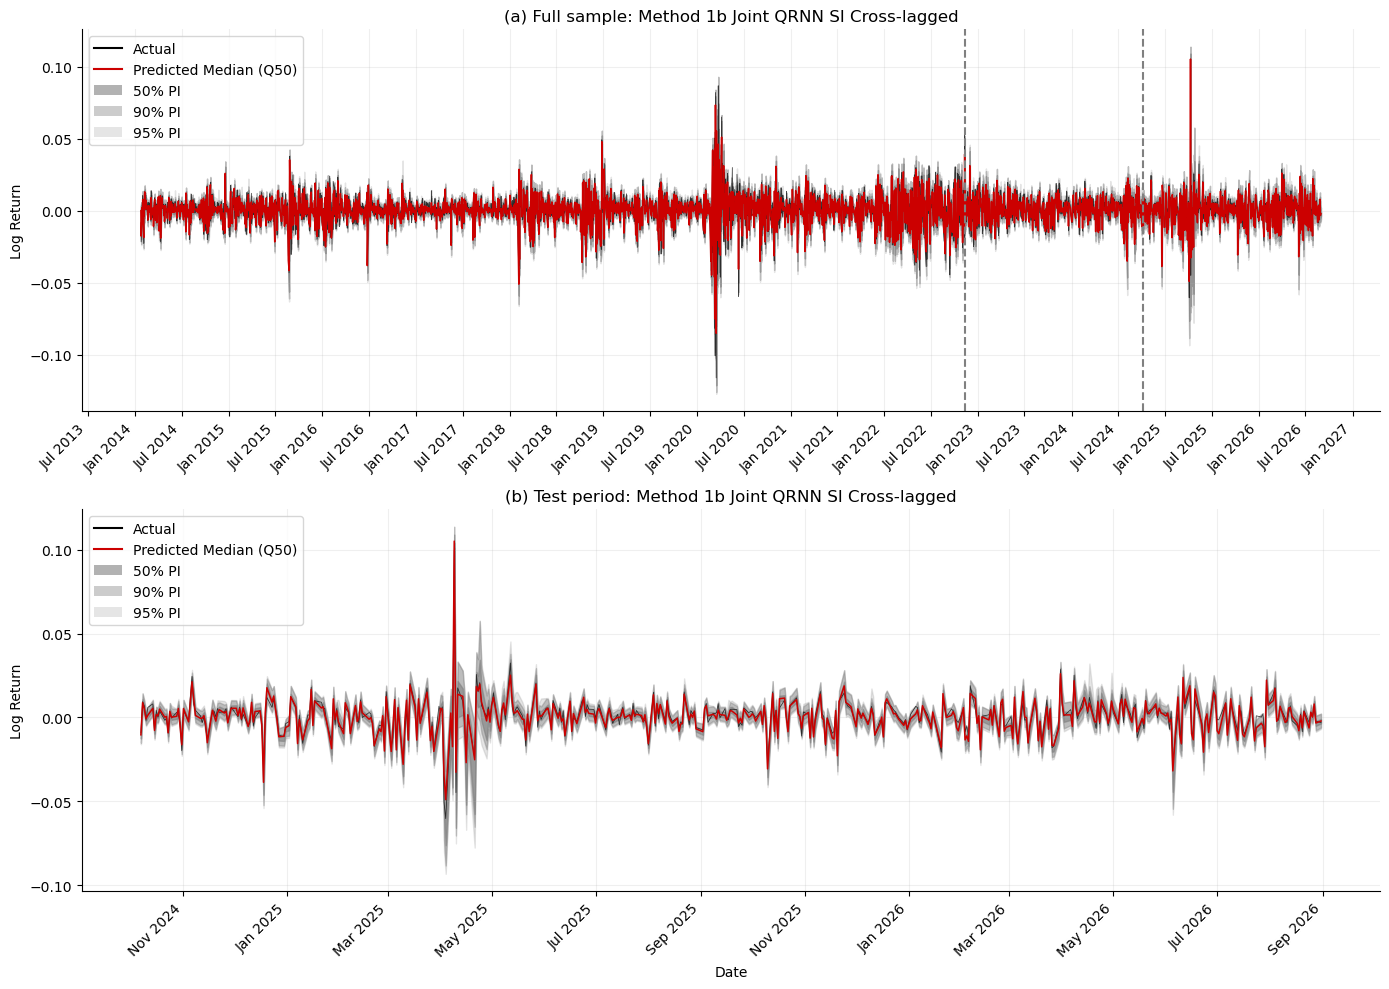

Plot saved to: spy_method1b_results/spy_method1b_joint_qrnn_si_cross/spy_method1b_joint_qrnn_si_cross_predictions.png

TEST METRICS -- METHOD 1B JOINT QRNN SI CROSS-LAGGED
 level       NLL  Hit_Rate      HRE    sigma
 0.025 -3.813377  0.010504 0.014496 0.000190
 0.050 -3.965845  0.021008 0.028992 0.000327
 0.250 -4.196539  0.182773 0.067227 0.000977
 0.500 -4.428112  0.432773 0.067227 0.001258
 0.750 -4.319630  0.741597 0.008403 0.001022
 0.950 -4.010273  0.972689 0.022689 0.000359
 0.975 -3.906131  0.985294 0.010294 0.000206

Average NLL: -4.091415
Average HRE: 0.03133253

CROSSOVER ANALYSIS -- FINAL METHOD 1B FORECASTS
 Lower  Upper  Violations  Rate
 0.025  0.050           0   0.0
 0.050  0.250           0   0.0
 0.250  0.500           0   0.0
 0.500  0.750           0   0.0
 0.750  0.950           0   0.0
 0.950  0.975           0   0.0

Total violations: 0
Tail violations: 0

LEARNED SPACING DIAGNOSTICS -- TEST PERIOD
Spacing  Lower_Level  Upper_Level  Mean_Delta  Minimum_Delta  M

In [17]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# ============================================================
# PLOT AND EVALUATE METHOD 1B -- QRNN S
# Self-LAGGED
# ============================================================

m1b_plot_pairs = list(zip(m1b_levels[:-1], m1b_levels[1:]))
m1b_plot_tail_pairs = [(0.025, 0.050), (0.950, 0.975)]

if 'm1b_best_model' not in globals():
    m1b_plot_checkpoint_filename = (
        M1B_OUTPUT_DIR / f'{m1b_model_tag}_best.pt'
    )
    m1b_plot_checkpoint = torch.load(
        m1b_plot_checkpoint_filename,
        map_location='cpu',
        weights_only=False,
    )
    m1b_best_model = Method1BJointHybrid(
        X_train.shape[1], m1b_plot_checkpoint['config']
    )
    m1b_best_model.load_state_dict(
        m1b_plot_checkpoint['model_state_dict']
    )

m1b_best_model.eval()

m1b_plot_X_all = torch.tensor(
    df[feature_cols].values, dtype=torch.float32
)
m1b_plot_y_all = torch.tensor(
    df['log_return'].values, dtype=torch.float32
)

with torch.no_grad():
    (
        m1b_plot_forecasts_all,
        m1b_plot_sigma,
        _,
        _,
        _,
        m1b_plot_spacings_all,
    ) = m1b_best_model(m1b_plot_y_all, m1b_plot_X_all)

m1b_plot_forecasts_np = m1b_plot_forecasts_all.cpu().numpy()
m1b_plot_spacings_np = m1b_plot_spacings_all.cpu().numpy()
m1b_plot_test_start = len(train_df) + len(val_df)
m1b_plot_forecasts_test = m1b_plot_forecasts_all[
    m1b_plot_test_start:
]
m1b_plot_spacings_test = m1b_plot_spacings_all[m1b_plot_test_start:]
m1b_plot_y_test = m1b_plot_y_all[m1b_plot_test_start:]

if len(m1b_plot_forecasts_test) != len(test_df):
    raise ValueError(
        'Test forecast length does not match test_df. Check the split.'
    )


def m1b_draw_panel(axis, dates, actual, forecasts):
    axis.plot(dates, actual, color='#000000', linewidth=0.6, alpha=0.7)
    axis.plot(
        dates, forecasts[:, 3], color='#CC0000', linewidth=1.1
    )
    axis.fill_between(
        dates, forecasts[:, 0], forecasts[:, 6],
        color='#808080', alpha=0.20,
    )
    axis.fill_between(
        dates, forecasts[:, 1], forecasts[:, 5],
        color='#808080', alpha=0.40,
    )
    axis.fill_between(
        dates, forecasts[:, 2], forecasts[:, 4],
        color='#808080', alpha=0.60,
    )
    axis.set_ylabel('Log Return')
    axis.grid(True, alpha=0.2)
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)


m1b_plot_distribution_label = M1B_DISTRIBUTION.upper()
m1b_plot_form_label = M1B_FORM.upper()
m1b_plot_lag_label = M1B_LAG.title()
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

m1b_draw_panel(
    axes[0], df.index, df['log_return'].values, m1b_plot_forecasts_np
)
axes[0].axvline(train_df.index[-1], color='gray', linestyle='--')
axes[0].axvline(val_df.index[-1], color='gray', linestyle='--')
axes[0].set_title(
    f'(a) Full sample: Method 1b Joint {m1b_plot_distribution_label} '
    f'{m1b_plot_form_label} {m1b_plot_lag_label}-lagged'
)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))

m1b_draw_panel(
    axes[1],
    test_df.index,
    test_df['log_return'].values,
    m1b_plot_forecasts_np[m1b_plot_test_start:],
)
axes[1].set_title(
    f'(b) Test period: Method 1b Joint '
    f'{m1b_plot_distribution_label} {m1b_plot_form_label} '
    f'{m1b_plot_lag_label}-lagged'
)
axes[1].set_xlabel('Date')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))

if M1B_DISTRIBUTION == 'qrnn':
    median_label = 'Predicted Median (Q50)'
    band_labels = ['50% PI', '90% PI', '95% PI']
else:
    median_label = 'Predicted median expectile'
    band_labels = [
        '0.25--0.75 expectile band',
        '0.05--0.95 expectile band',
        '0.025--0.975 expectile band',
    ]

m1b_legend = [
    Line2D([0], [0], color='#000000', label='Actual'),
    Line2D([0], [0], color='#CC0000', label=median_label),
    Patch(facecolor='#808080', alpha=0.60, label=band_labels[0]),
    Patch(facecolor='#808080', alpha=0.40, label=band_labels[1]),
    Patch(facecolor='#808080', alpha=0.20, label=band_labels[2]),
]
for axis in axes:
    axis.legend(handles=m1b_legend, loc='upper left')
    plt.setp(
        axis.xaxis.get_majorticklabels(), rotation=45, ha='right'
    )

plt.tight_layout()
m1b_plot_png = (
    M1B_OUTPUT_DIR / f'{m1b_model_tag}_predictions.png'
)
plt.savefig(m1b_plot_png, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f'Plot saved to: {m1b_plot_png}')


# ============================================================
# Test metrics by level
# ============================================================

m1b_plot_metric_rows = []
m1b_plot_nll_columns = []
for index, level in enumerate(m1b_levels):
    forecast = m1b_plot_forecasts_test[:, index]
    sigma = m1b_plot_sigma[index]
    residual = m1b_plot_y_test - forecast

    if M1B_DISTRIBUTION == 'qrnn':
        indicator = (residual < 0).to(residual.dtype)
        check_loss = residual * (level - indicator)
        nll_by_observation = (
            -torch.log(residual.new_tensor(level * (1 - level)))
            + torch.log(sigma)
            + check_loss / sigma
        )
        nll = nll_by_observation.mean().item()
        m1b_plot_nll_columns.append(
            nll_by_observation.detach().cpu().numpy()
        )
        hit_rate = (
            m1b_plot_y_test <= forecast
        ).float().mean().item()
        secondary = abs(hit_rate - level)
        row = {
            'level': level,
            'NLL': nll,
            'Hit_Rate': hit_rate,
            'HRE': secondary,
            'sigma': sigma.item(),
        }
    else:
        weight = torch.abs(
            residual.new_tensor(level)
            - (residual < 0).to(residual.dtype)
        )
        weighted_squared_error = weight * residual.square()
        constant = (
            torch.log(
                torch.sqrt(residual.new_tensor(torch.pi / level))
                + torch.sqrt(
                    residual.new_tensor(torch.pi / (1 - level))
                )
            )
            - np.log(2.0)
        )
        nll = (
            torch.log(sigma)
            + constant
            + weighted_squared_error / sigma.square()
        ).mean().item()
        secondary = weighted_squared_error.mean().item()
        row = {
            'level': level,
            'NLL': nll,
            'ASE': secondary,
            'sigma': sigma.item(),
        }

    m1b_plot_metric_rows.append(row)

m1b_plot_metrics_df = pd.DataFrame(m1b_plot_metric_rows)
m1b_plot_metric_column = (
    'HRE' if M1B_DISTRIBUTION == 'qrnn' else 'ASE'
)
print('\n' + '=' * 72)
print(
    f'TEST METRICS -- METHOD 1B JOINT '
    f'{m1b_plot_distribution_label} {m1b_plot_form_label} '
    f'{m1b_plot_lag_label.upper()}-LAGGED'
)
print('=' * 72)
print(m1b_plot_metrics_df.to_string(index=False))
print(f"\nAverage NLL: {m1b_plot_metrics_df['NLL'].mean():.6f}")
print(
    f'Average {m1b_plot_metric_column}: '
    f"{m1b_plot_metrics_df[m1b_plot_metric_column].mean():.8f}"
)


# ============================================================
# Crossover and learned-spacing diagnostics
# ============================================================

m1b_plot_crossover_rows = []
for index, (lower, upper) in enumerate(m1b_plot_pairs):
    count = int((
        m1b_plot_forecasts_test[:, index]
        > m1b_plot_forecasts_test[:, index + 1]
    ).sum().item())
    m1b_plot_crossover_rows.append({
        'Lower': lower,
        'Upper': upper,
        'Violations': count,
        'Rate': count / len(m1b_plot_y_test),
    })

m1b_plot_crossover_df = pd.DataFrame(m1b_plot_crossover_rows)
m1b_plot_total = int(m1b_plot_crossover_df['Violations'].sum())
m1b_plot_tail = int(
    m1b_plot_crossover_df.iloc[0]['Violations']
    + m1b_plot_crossover_df.iloc[-1]['Violations']
)
print('\n' + '=' * 72)
print('CROSSOVER ANALYSIS -- FINAL METHOD 1B FORECASTS')
print('=' * 72)
print(m1b_plot_crossover_df.to_string(index=False))
print(f'\nTotal violations: {m1b_plot_total}')
print(f'Tail violations: {m1b_plot_tail}')

m1b_plot_spacing_rows = []
for index, (name, pair) in enumerate(zip(
    m1b_spacing_names, m1b_plot_pairs
)):
    spacing = m1b_plot_spacings_test[:, index]
    m1b_plot_spacing_rows.append({
        'Spacing': name,
        'Lower_Level': pair[0],
        'Upper_Level': pair[1],
        'Mean_Delta': spacing.mean().item(),
        'Minimum_Delta': spacing.min().item(),
        'Maximum_Delta': spacing.max().item(),
        'Delta_Std': spacing.std(unbiased=False).item(),
        'Near_Zero_Count': int((spacing <= 1e-5).sum().item()),
        'Near_Zero_Rate': (
            spacing <= 1e-5
        ).float().mean().item(),
    })

m1b_plot_spacing_df = pd.DataFrame(m1b_plot_spacing_rows)
print('\n' + '=' * 72)
print('LEARNED SPACING DIAGNOSTICS -- TEST PERIOD')
print('=' * 72)
print(m1b_plot_spacing_df.to_string(index=False))


# ============================================================
# Detailed predictions and saved outputs
# ============================================================

m1b_plot_predictions_df = pd.DataFrame({
    'Date': pd.to_datetime(test_df.index),
    'Actual': test_df['log_return'].values,
})
m1b_plot_prefix = 'Q' if M1B_DISTRIBUTION == 'qrnn' else 'E'
for index, level in enumerate(m1b_levels):
    m1b_plot_predictions_df[f'{m1b_plot_prefix}_{level:.3f}'] = (
        m1b_plot_forecasts_np[m1b_plot_test_start:, index]
    )
for index, (lower, upper) in enumerate(m1b_plot_pairs):
    m1b_plot_predictions_df[
        f'Gap_{lower:.3f}_{upper:.3f}'
    ] = m1b_plot_spacings_np[m1b_plot_test_start:, index]

m1b_plot_nll_df = pd.DataFrame({
    'Date': pd.to_datetime(test_df.index),
})
for index, level in enumerate(m1b_levels):
    m1b_plot_nll_df[f'nll_{level:.3f}'] = m1b_plot_nll_columns[index]
m1b_plot_nll_df['average_nll'] = np.column_stack(
    m1b_plot_nll_columns
).mean(axis=1)

m1b_plot_metrics_file = M1B_OUTPUT_DIR / f'{m1b_model_tag}_test_metrics.csv'
m1b_plot_crossover_file = M1B_OUTPUT_DIR / f'{m1b_model_tag}_crossover.csv'
m1b_plot_spacing_file = M1B_OUTPUT_DIR / f'{m1b_model_tag}_delta_summary.csv'
m1b_plot_predictions_file = M1B_OUTPUT_DIR / f'{m1b_model_tag}_test_predictions.csv'
m1b_plot_nll_file = M1B_OUTPUT_DIR / f'{m1b_model_tag}_test_nll_by_date.csv'

m1b_plot_metrics_df.to_csv(m1b_plot_metrics_file, index=False)
m1b_plot_crossover_df.to_csv(m1b_plot_crossover_file, index=False)
m1b_plot_spacing_df.to_csv(m1b_plot_spacing_file, index=False)
m1b_plot_predictions_df.to_csv(m1b_plot_predictions_file, index=False)
m1b_plot_nll_df.to_csv(m1b_plot_nll_file, index=False)

print('\nSaved Method 1b outputs:')
for filename in (
    m1b_plot_png,
    m1b_plot_metrics_file,
    m1b_plot_crossover_file,
    m1b_plot_spacing_file,
    m1b_plot_predictions_file,
    m1b_plot_nll_file,
):
    print(f'  {filename}')



## Crossover - Method 3

Sequential learned positive adjacent spacing. Run the tuning cell first and then the plotting/test cell.


In [20]:
"""Method 3, Specification 1: Hybrid QRNN SI cross-lagged.

Run this after the notebook has created the four tensors
``y_train``, ``X_train``, ``y_val`` and ``X_val``.

The median is the corresponding original hybrid model.  Every non-median
network predicts a raw adjacent gap; ``softplus`` makes that gap positive and
the target level is reconstructed from its already-fitted adjacent reference.
There is no fixed epsilon boundary, max/min projection, or crossover penalty.
"""

from __future__ import annotations

import copy
from pathlib import Path

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from optuna.samplers import TPESampler


# ---------------------------------------------------------------------------
# User settings
# ---------------------------------------------------------------------------

LEVELS = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
ESTIMATION_ORDER = [0.500, 0.750, 0.950, 0.975, 0.250, 0.050, 0.025]
REFERENCE_LEVEL = {
    0.500: None,
    0.750: 0.500,
    0.950: 0.750,
    0.975: 0.950,
    0.250: 0.500,
    0.050: 0.250,
    0.025: 0.050,
}
DIRECTION = {
    0.500: None,
    0.750: "upper",
    0.950: "upper",
    0.975: "upper",
    0.250: "lower",
    0.050: "lower",
    0.025: "lower",
}

N_TRIALS = 200
MAX_EPOCHS = 200
BASE_SEED = 2026
PSI_MARGIN = 1e-4
INITIAL_DELTA_BIAS = -4.6  # softplus(-4.6) is about 0.01; trainable.
OUTPUT_DIR = Path("spy_method3_spacing_qrnn_si_cross_results")

# This standalone chunk estimates only the model supplied by the user:
# SPY Hybrid QRNN, SI form, cross-lagged recursion.
MODELS_TO_RUN = [("qrnn", "si", "cross")]


def validate_notebook_inputs():
    required = ("y_train", "X_train", "y_val", "X_val")
    missing = [name for name in required if name not in globals()]
    if missing:
        raise NameError(
            "Create these notebook tensors before running Method 3: "
            + ", ".join(missing)
        )
    for y_name, x_name in (("y_train", "X_train"), ("y_val", "X_val")):
        y_value, x_value = globals()[y_name], globals()[x_name]
        if not isinstance(y_value, torch.Tensor) or not isinstance(x_value, torch.Tensor):
            raise TypeError(f"{y_name} and {x_name} must be torch tensors.")
        if y_value.ndim != 1 or x_value.ndim != 2 or len(y_value) != len(x_value):
            raise ValueError(f"{y_name} must be (T,) and {x_name} must be (T,p).")


# ---------------------------------------------------------------------------
# Generic Method 3 model
# ---------------------------------------------------------------------------

class Method3SpacingModel(nn.Module):
    """One sequential level model.

    direction=None is the median hybrid model.  Otherwise the network is a
    pure learned-spacing model and deliberately has no redundant statistical
    or mixing parameters.
    """

    def __init__(self, input_dim, config, distribution, form, lag, direction=None):
        super().__init__()
        if distribution not in {"qrnn", "ernn"}:
            raise ValueError("distribution must be 'qrnn' or 'ernn'.")
        if form not in {"s", "a", "si"}:
            raise ValueError("form must be 's', 'a', or 'si'.")
        if lag not in {"self", "cross"}:
            raise ValueError("lag must be 'self' or 'cross'.")

        self.distribution = distribution
        self.form = form
        self.lag = lag
        self.direction = direction

        # Statistical and mixing parameters are identifiable only for median.
        if direction is None:
            self.persistence_raw = nn.Parameter(torch.tensor(1.386))
            self.news1_raw = nn.Parameter(torch.tensor(0.3))
            if form in {"a", "si"}:
                self.news2_raw = nn.Parameter(torch.tensor(0.3))
            self.psi_raw = nn.Parameter(torch.tensor(0.0))

        self.sigma_raw = nn.Parameter(torch.tensor(0.5))
        fnn_input_dim = input_dim if direction is None else input_dim + 1
        layers = []
        previous_dim = fnn_input_dim
        for index in range(config["n_hidden_layers"]):
            hidden_dim = config[f"hidden_dim_{index}"]
            layers.append(nn.Linear(previous_dim, hidden_dim))
            if config["layernorm"]:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(self._activation(config["activation"]))
            if config["dropout"] > 0:
                layers.append(nn.Dropout(config["dropout"]))
            previous_dim = hidden_dim
        layers.append(nn.Linear(previous_dim, 1))
        self.fnn = nn.Sequential(*layers)
        self._initialise_fnn(config["weight_init"])

        if direction is not None:
            nn.init.constant_(self.fnn[-1].bias, INITIAL_DELTA_BIAS)

    @staticmethod
    def _activation(name):
        return {
            "relu": nn.ReLU(),
            "elu": nn.ELU(),
            "gelu": nn.GELU(),
            "tanh": nn.Tanh(),
        }[name]

    def _initialise_fnn(self, method):
        for module in self.fnn.modules():
            if isinstance(module, nn.Linear):
                if method == "glorot":
                    nn.init.xavier_uniform_(module.weight)
                else:
                    nn.init.kaiming_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def _statistical_update(self, previous_state, previous_y):
        persistence = torch.sigmoid(self.persistence_raw)
        news1 = F.softplus(self.news1_raw)
        if self.form == "s":
            return persistence * previous_state + news1 * torch.abs(previous_y)
        if self.form == "a":
            news2 = F.softplus(self.news2_raw)
            return (
                persistence * previous_state
                + news1 * torch.clamp(previous_y, min=0)
                + news2 * torch.clamp(-previous_y, min=0)
            )
        news2 = F.softplus(self.news2_raw)
        absolute_y = torch.abs(previous_y)
        return (
            persistence * previous_state
            + news1 * absolute_y
            + news2 * previous_state * absolute_y
        )

    def forward(self, y, X, q_reference=None, initial_state=None, initial_y=None):
        sigma = F.softplus(self.sigma_raw) + 1e-6

        # Six non-median models: directly learn a positive adjacent spacing.
        if self.direction is not None:
            if q_reference is None:
                raise ValueError("Non-median levels require q_reference.")
            reference = q_reference.detach()
            raw_delta = self.fnn(
                torch.cat((X, reference.unsqueeze(1)), dim=1)
            ).squeeze(-1)
            delta = F.softplus(raw_delta)
            prediction = reference + delta if self.direction == "upper" else reference - delta
            return prediction, torch.zeros_like(prediction), raw_delta, delta, sigma

        # Median: original hybrid statistical-neural specification.
        if (initial_state is None) != (initial_y is None):
            raise ValueError("initial_state and initial_y must be supplied together.")
        has_initial_state = initial_state is not None
        previous_state = initial_state if has_initial_state else y.new_zeros(())
        fnn_median = self.fnn(X).squeeze(-1)
        psi = (1.0 - PSI_MARGIN) * torch.sigmoid(self.psi_raw)
        predictions, statistical_outputs = [], []

        for t in range(len(y)):
            if t == 0 and not has_initial_state:
                statistical_t = y.new_zeros(())
                hybrid_t = y.new_zeros(())
            else:
                previous_y = initial_y if t == 0 else y[t - 1]
                statistical_t = self._statistical_update(previous_state, previous_y)
                hybrid_t = psi * statistical_t + (1.0 - psi) * fnn_median[t]
            statistical_outputs.append(statistical_t)
            predictions.append(hybrid_t)
            # Settled convention used by the earlier code:
            # self -> previous pure statistical output; cross -> previous hybrid.
            previous_state = statistical_t if self.lag == "self" else hybrid_t

        prediction = torch.stack(predictions)
        statistical = torch.stack(statistical_outputs)
        return prediction, statistical, fnn_median, None, sigma


# ---------------------------------------------------------------------------
# Distribution-specific objectives and calibration metrics
# ---------------------------------------------------------------------------

def single_level_nll(y, location, sigma, level, distribution):
    residual = y - location
    level_tensor = torch.tensor(level, dtype=y.dtype, device=y.device)
    if distribution == "qrnn":
        indicator = (residual < 0).to(y.dtype)
        rho = residual * (level_tensor - indicator)
        return (
            -torch.log(level_tensor * (1.0 - level_tensor))
            + torch.log(sigma)
            + rho / sigma
        ).mean()

    weight = torch.abs(level_tensor - (residual < 0).to(y.dtype))
    omega = weight * residual.square()
    constant = (
        torch.log(
            torch.sqrt(torch.pi / level_tensor)
            + torch.sqrt(torch.pi / (1.0 - level_tensor))
        )
        - np.log(2.0)
    )
    return (torch.log(sigma) + constant + omega / sigma.square()).mean()


def qrnn_calibration(y, location, level):
    if level <= 0.5:
        empirical = (y <= location).float().mean().item()
        target = level
    else:
        empirical = (y > location).float().mean().item()
        target = 1.0 - level
    crp = empirical / target
    return {"hit_rate": (y <= location).float().mean().item(),
            "hre": abs((y <= location).float().mean().item() - level),
            "calibration": crp,
            "calibration_penalty": (crp - 1.0) ** 2}


def ernn_calibration(y, location, level):
    residual = y - location
    weights = torch.where(
        residual >= 0,
        torch.full_like(residual, level),
        torch.full_like(residual, 1.0 - level),
    )
    ase = (weights * residual.square()).mean().item()
    return {"ase": ase, "calibration": ase, "calibration_penalty": ase}


# ---------------------------------------------------------------------------
# Tuning helpers
# ---------------------------------------------------------------------------

def suggest_config(trial):
    config = {
        "n_hidden_layers": trial.suggest_int("n_hidden_layers", 1, 3),
        "activation": trial.suggest_categorical("activation", ["relu", "elu", "gelu", "tanh"]),
        "dropout": trial.suggest_float("dropout", 0.0, 0.5),
        "layernorm": trial.suggest_categorical("layernorm", [True, False]),
        "weight_init": trial.suggest_categorical("weight_init", ["glorot", "he"]),
        "lr": trial.suggest_float("lr", 1e-4, 5e-2, log=True),
        "optimizer": trial.suggest_categorical("optimizer", ["adam", "adamw"]),
        "weight_decay": trial.suggest_float("weight_decay", 0.0, 1e-4),
        "gradient_clip": trial.suggest_categorical("gradient_clip", [0.1, 1.0, 5.0]),
        "patience": trial.suggest_categorical("patience", [10, 20, 30]),
    }
    for index in range(config["n_hidden_layers"]):
        config[f"hidden_dim_{index}"] = trial.suggest_int(f"hidden_dim_{index}", 32, 256)
    return config


def make_optimizer(model, config):
    optimizer_class = torch.optim.Adam if config["optimizer"] == "adam" else torch.optim.AdamW
    return optimizer_class(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])


def median_validation_state(model, statistical_train, prediction_train):
    return statistical_train[-1] if model.lag == "self" else prediction_train[-1]


def predict_train_val(model, direction, q_reference_train=None, q_reference_val=None):
    model.eval()
    with torch.no_grad():
        q_train, stat_train, _, delta_train, _ = model(
            y_train, X_train, q_reference_train
        )
        if direction is None:
            q_val, _, _, delta_val, sigma = model(
                y_val,
                X_val,
                initial_state=median_validation_state(model, stat_train, q_train),
                initial_y=y_train[-1],
            )
        else:
            q_val, _, _, delta_val, sigma = model(y_val, X_val, q_reference_val)
    return q_train.detach(), q_val.detach(), delta_train, delta_val, sigma.detach()


def train_config(spec, config, level, direction, q_ref_train, q_ref_val, seed):
    distribution, form, lag = spec
    torch.manual_seed(seed)
    model = Method3SpacingModel(
        X_train.shape[1], config, distribution, form, lag, direction
    )
    optimizer = make_optimizer(model, config)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=10, factor=0.5, min_lr=1e-6
    )
    best_loss, counter, best_state = float("inf"), 0, None

    for _ in range(MAX_EPOCHS):
        model.train()
        optimizer.zero_grad()
        q_train, _, _, _, sigma = model(y_train, X_train, q_ref_train)
        loss = single_level_nll(y_train[1:], q_train[1:], sigma, level, distribution)
        if not torch.isfinite(loss):
            return None
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config["gradient_clip"])
        optimizer.step()

        model.eval()
        with torch.no_grad():
            _, q_val, _, _, sigma_val = predict_train_val(
                model, direction, q_ref_train, q_ref_val
            )
            val_loss = single_level_nll(y_val, q_val, sigma_val, level, distribution)
        scheduler.step(val_loss.item())
        if val_loss.item() < best_loss:
            best_loss, counter = val_loss.item(), 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            counter += 1
            if counter >= config["patience"]:
                break

    if best_state is None:
        return None
    model.load_state_dict(best_state)
    return model


def transformed_median_parameters(model):
    if model.direction is not None:
        return {}
    result = {
        "persistence": torch.sigmoid(model.persistence_raw).item(),
        "news1": F.softplus(model.news1_raw).item(),
        "psi": ((1.0 - PSI_MARGIN) * torch.sigmoid(model.psi_raw)).item(),
    }
    result["news2"] = (
        F.softplus(model.news2_raw).item() if hasattr(model, "news2_raw") else np.nan
    )
    return result


def evaluate(model, level, direction, q_ref_train, q_ref_val):
    _, q_val, _, delta_val, sigma = predict_train_val(
        model, direction, q_ref_train, q_ref_val
    )
    metrics = {
        "nll": single_level_nll(
            y_val, q_val, sigma, level, model.distribution
        ).item(),
        "sigma": (F.softplus(model.sigma_raw) + 1e-6).item(),
        "mean_delta": np.nan if delta_val is None else delta_val.mean().item(),
        "min_delta": np.nan if delta_val is None else delta_val.min().item(),
        "max_delta": np.nan if delta_val is None else delta_val.max().item(),
        "sd_delta": np.nan if delta_val is None else delta_val.std(unbiased=False).item(),
    }
    metrics.update(
        qrnn_calibration(y_val, q_val, level)
        if model.distribution == "qrnn"
        else ernn_calibration(y_val, q_val, level)
    )
    metrics.update(transformed_median_parameters(model))
    return metrics


def select_trial(study):
    trials = [
        trial for trial in study.trials
        if trial.state == optuna.trial.TrialState.COMPLETE
        and trial.value is not None
        and np.isfinite(trial.value)
        and "calibration_penalty" in trial.user_attrs
    ]
    if not trials:
        raise RuntimeError("No valid completed Optuna trials.")
    for rank, trial in enumerate(sorted(trials, key=lambda x: x.user_attrs["nll"]), 1):
        trial._rank_nll = rank
    for rank, trial in enumerate(
        sorted(trials, key=lambda x: x.user_attrs["calibration_penalty"]), 1
    ):
        trial._rank_calibration = rank
    best = min(
        trials,
        key=lambda x: (
            x._rank_nll + x._rank_calibration,
            x.user_attrs["nll"],
            x.user_attrs["calibration_penalty"],
            x.number,
        ),
    )
    return best, trials


def count_crossovers(predictions):
    matrix = torch.stack([predictions[level] for level in LEVELS], dim=1)
    violations = matrix[:, :-1] > matrix[:, 1:]
    pair_counts = violations.sum(dim=0)
    return {
        "crossover": int(violations.sum().item()),
        "tail": int((pair_counts[0] + pair_counts[-1]).item()),
    }


def run_one_model(spec):
    distribution, form, lag = spec
    model_key = f"{distribution}_{form}_{lag}"
    model_dir = OUTPUT_DIR / model_key
    model_dir.mkdir(parents=True, exist_ok=True)
    print("\n" + "=" * 78)
    print(f"METHOD 3 SPACING: {distribution.upper()} {form.upper()} {lag.upper()}")
    print("=" * 78)

    models, configs, metrics_by_level = {}, {}, {}
    train_predictions, val_predictions = {}, {}
    train_deltas, val_deltas = {}, {}

    for order_index, level in enumerate(ESTIMATION_ORDER):
        reference_level = REFERENCE_LEVEL[level]
        direction = DIRECTION[level]
        q_ref_train = None if reference_level is None else train_predictions[reference_level]
        q_ref_val = None if reference_level is None else val_predictions[reference_level]
        seed = BASE_SEED + 1000 * MODELS_TO_RUN.index(spec) + order_index

        def objective(trial):
            config = suggest_config(trial)
            model = train_config(
                spec, config, level, direction, q_ref_train, q_ref_val, seed
            )
            if model is None:
                return float("inf")
            trial_metrics = evaluate(model, level, direction, q_ref_train, q_ref_val)
            for name, value in trial_metrics.items():
                trial.set_user_attr(name, value)
            return trial_metrics["nll"]

        print(
            f"Level={level:.3f} | reference={reference_level} | "
            f"direction={direction} | trials={N_TRIALS}"
        )
        study = optuna.create_study(
            direction="minimize", sampler=TPESampler(seed=seed)
        )
        study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
        best_trial, valid_trials = select_trial(study)

        ranking_records = []
        for trial in valid_trials:
            record = {
                "distribution": distribution,
                "form": form,
                "lag": lag,
                "level": level,
                "reference_level": reference_level,
                "direction": direction,
                "trial": trial.number,
                "nll": trial.user_attrs["nll"],
                "calibration": trial.user_attrs["calibration"],
                "calibration_penalty": trial.user_attrs["calibration_penalty"],
                "rank_nll": trial._rank_nll,
                "rank_calibration": trial._rank_calibration,
                "sum_rank": trial._rank_nll + trial._rank_calibration,
            }
            record.update(trial.user_attrs)
            record.update(trial.params)
            ranking_records.append(record)
        pd.DataFrame(ranking_records).sort_values(
            ["sum_rank", "nll", "calibration_penalty"]
        ).to_csv(model_dir / f"ranking_level_{level:.3f}.csv", index=False)

        best_config = best_trial.params.copy()
        final_model = train_config(
            spec, best_config, level, direction, q_ref_train, q_ref_val, seed
        )
        if final_model is None:
            raise RuntimeError(f"Selected refit failed for {model_key}, level={level}.")
        final_metrics = evaluate(
            final_model, level, direction, q_ref_train, q_ref_val
        )
        q_train, q_val, delta_train, delta_val, _ = predict_train_val(
            final_model, direction, q_ref_train, q_ref_val
        )
        models[level], configs[level] = final_model, best_config
        metrics_by_level[level] = final_metrics
        train_predictions[level], val_predictions[level] = q_train, q_val
        train_deltas[level], val_deltas[level] = delta_train, delta_val

        print(
            f"Selected trial #{best_trial.number} | "
            f"val NLL={final_metrics['nll']:.6f} | "
            f"calibration={final_metrics['calibration']:.6f} | "
            f"mean delta={final_metrics['mean_delta']:.6f}"
        )

    crossing = count_crossovers(val_predictions)
    average_nll = float(np.mean([metrics_by_level[x]["nll"] for x in LEVELS]))
    if distribution == "qrnn":
        average_secondary = float(np.mean([metrics_by_level[x]["hre"] for x in LEVELS]))
        secondary_name = "hre"
    else:
        average_secondary = float(np.mean([metrics_by_level[x]["ase"] for x in LEVELS]))
        secondary_name = "ase"

    checkpoint = {
        "model_name": f"Method 3 spacing {distribution.upper()} {form.upper()} {lag}",
        "specification": "learned_positive_time_varying_adjacent_spacing",
        "distribution": distribution,
        "form": form,
        "lag": lag,
        "levels": LEVELS,
        "estimation_order": ESTIMATION_ORDER,
        "reference_level": REFERENCE_LEVEL,
        "direction": DIRECTION,
        "configs": configs,
        "model_state_dicts": {level: model.state_dict() for level, model in models.items()},
        "validation_metrics": metrics_by_level,
        "validation_summary": {
            "average_nll": average_nll,
            f"average_{secondary_name}": average_secondary,
            **crossing,
        },
    }
    checkpoint_path = model_dir / f"method3_spacing_{model_key}_best.pt"
    torch.save(checkpoint, checkpoint_path)

    level_rows = []
    for level in LEVELS:
        level_rows.append({"level": level, **metrics_by_level[level]})
    pd.DataFrame(level_rows).to_csv(model_dir / "validation_by_level.csv", index=False)

    summary = {
        "distribution": distribution,
        "form": form.upper(),
        "lag": lag,
        "average_nll": average_nll,
        "average_hre": average_secondary if distribution == "qrnn" else np.nan,
        "average_ase": average_secondary if distribution == "ernn" else np.nan,
        **crossing,
        "checkpoint": str(checkpoint_path),
    }
    pd.DataFrame([summary]).to_csv(model_dir / "validation_summary.csv", index=False)
    print(f"Saved {checkpoint_path}")
    return summary


def main():
    validate_notebook_inputs()
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    summaries = []
    for spec in MODELS_TO_RUN:
        summaries.append(run_one_model(spec))
        pd.DataFrame(summaries).to_csv(
            OUTPUT_DIR / "spy_method3_qrnn_si_cross_validation_summary.csv", index=False
        )
    print("\nMethod 3 SPY QRNN SI cross-lagged estimation is complete.")
    print(pd.DataFrame(summaries).to_string(index=False))


if __name__ == "__main__":
    main()

[I 2026-09-26 14:34:54,827] A new study created in memory with name: no-name-30875e28-7878-47ce-8245-cd957319f71d



METHOD 3 SPACING: QRNN SI CROSS
Level=0.500 | reference=None | direction=None | trials=200


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-09-26 14:35:25,168] Trial 0 finished with value: 1.2859792709350586 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 1.2859792709350586.
[I 2026-09-26 14:35:59,135] Trial 1 finished with value: 0.2232920080423355 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: 0.2232920080423355.
[I 2026-09-26 14:36:07,447] Trial 2 finished with value: 1.3935813903808594 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.37112272198735796, 'layernorm': True, '

[I 2026-09-26 18:31:49,808] A new study created in memory with name: no-name-ba342f0f-656a-423b-8dd2-fdf9be2e560a


...

[I 2026-09-26 19:02:45,031] Trial 0 finished with value: 1.9679430723190308 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.11155263989652436, 'layernorm': False, 'weight_init': 'glorot', 'lr': 0.007027131382827591, 'optimizer': 'adam', 'weight_decay': 1.3627456384020455e-05, 'gradient_clip': 0.1, 'patience': 20, 'hidden_dim_0': 210, 'hidden_dim_1': 162}. Best is trial 0 with value: 1.9679430723190308.
[I 2026-09-26 19:02:47,913] Trial 1 finished with value: 0.6878865361213684 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.09630890988459678, 'layernorm': False, 'weight_init': 'he', 'lr': 0.014080280114638532, 'optimizer': 'adam', 'weight_decay': 6.431370011304687e-05, 'gradient_clip': 0.1, 'patience': 10, 'hidden_dim_0': 88, 'hidden_dim_1': 196, 'hidden_dim_2': 94}. Best is trial 1 with value: 0.6878865361213684.
[I 2026-09-26 19:02:49,471] Trial 2 finished with value: 2.9157450199127197 and parameters: {'n_hidden_layers': 2, 'activat

[I 2026-09-26 19:10:36,189] A new study created in memory with name: no-name-a4792bf8-e64a-415a-b100-ef30a1c7c2df


Selected trial #187 | val NLL=-4.077388 | calibration=1.010526 | mean delta=0.002805
Level=0.025 | reference=0.05 | direction=lower | trials=200


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-09-26 19:10:38,281] Trial 0 finished with value: 2.487046957015991 and parameters: {'n_hidden_layers': 3, 'activation': 'relu', 'dropout': 0.11110238679748752, 'layernorm': False, 'weight_init': 'he', 'lr': 0.007412946243424984, 'optimizer': 'adam', 'weight_decay': 2.0378044529961404e-05, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 189, 'hidden_dim_1': 194, 'hidden_dim_2': 105}. Best is trial 0 with value: 2.487046957015991.
[I 2026-09-26 19:10:40,236] Trial 1 finished with value: 3.394390821456909 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.40125521853112683, 'layernorm': False, 'weight_init': 'he', 'lr': 0.002129411642087111, 'optimizer': 'adamw', 'weight_decay': 1.3495676574961092e-06, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 133, 'hidden_dim_1': 222, 'hidden_dim_2': 66}. Best is trial 0 with value: 2.487046957015991.
[I 2026-09-26 19:10:40,887] Trial 2 finished with value: 3.5387556552886963 and parameters: {'n_hidden_laye

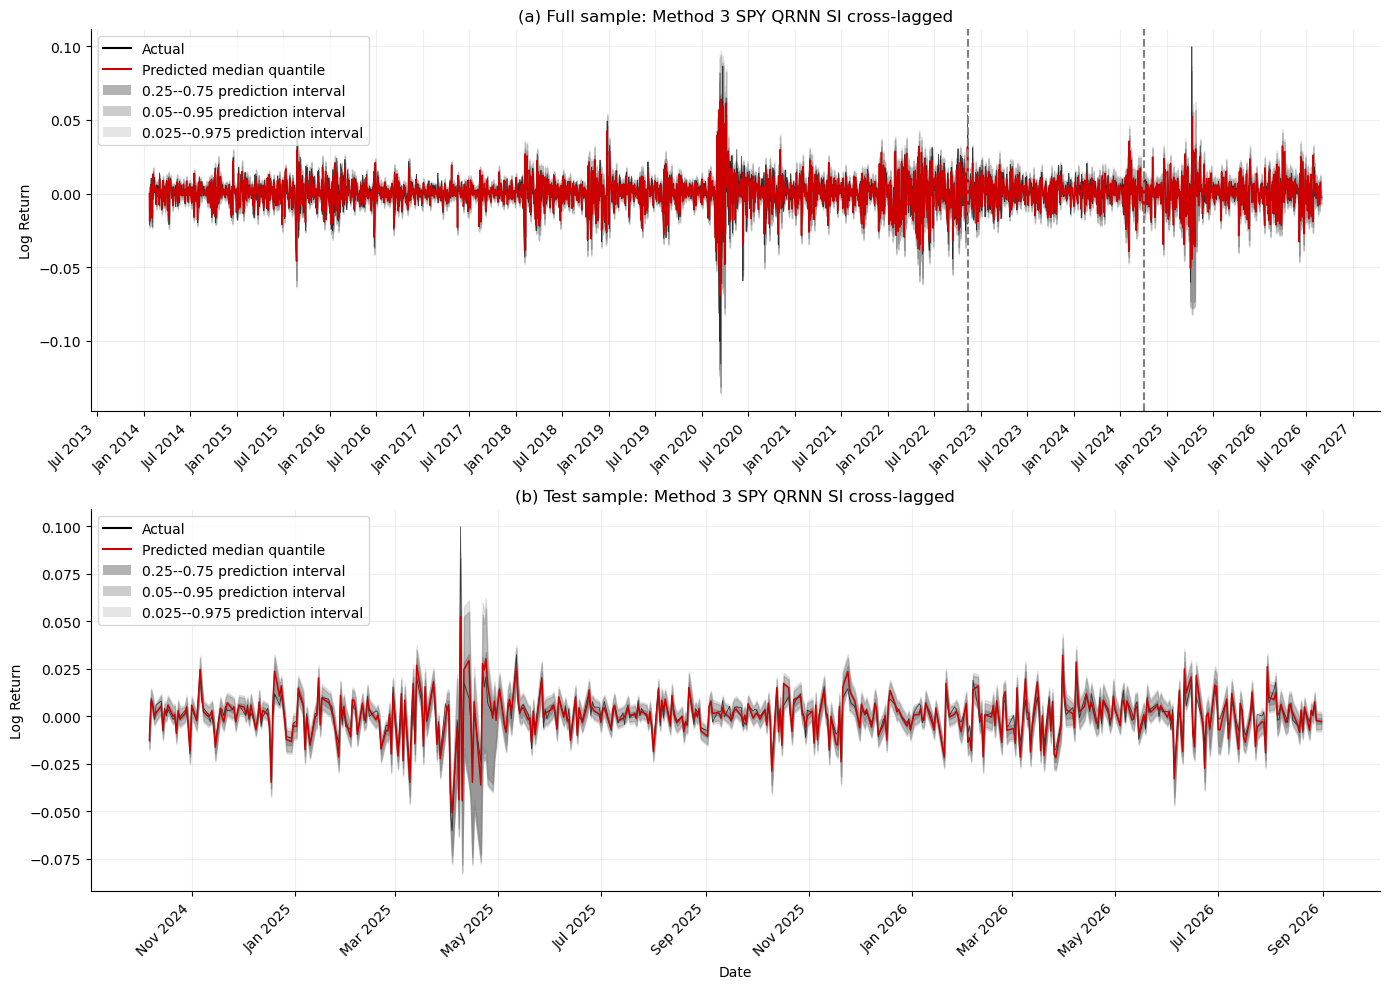


METHOD 3 SPY QRNN SI CROSS-LAGGED -- TEST RESULTS
                     model  test_T  average_nll  average_hre  crossover  tail
Method 3 SPY QRNN SI Cross     476    -3.825428     0.027311          0     0

Per-level results:
 alpha       nll  hit_rate      hre    sigma
 0.025 -3.657009  0.008403 0.016597 0.000167
 0.050 -3.756717  0.027311 0.022689 0.000300
 0.250 -3.931686  0.184874 0.065126 0.001144
 0.500 -4.098673  0.476891 0.023109 0.001535
 0.750 -4.061319  0.699580 0.050420 0.001196
 0.950 -3.681893  0.936975 0.013025 0.000354
 0.975 -3.590699  0.974790 0.000210 0.000197

Learned-spacing diagnostics:
 alpha  reference_alpha direction  mean_delta  min_delta  max_delta     sd_delta  near_zero_count  near_zero_rate
 0.025             0.05     lower    0.001073   0.001073   0.001074 2.468531e-07                0             0.0
 0.050             0.25     lower    0.003040   0.002238   0.003805 3.323798e-04                0             0.0
 0.250             0.50     lower    0.00

In [22]:
"""Plot and evaluate Method 3 SPY QRNN SI cross-lagged on the test sample.

Run after the tuning/data-preparation code. Expected notebook objects:
df, train_df, val_df, test_df, feature_cols, X_train and Method3SpacingModel.
"""

from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


LEVELS = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
ORDER = [0.500, 0.750, 0.950, 0.975, 0.250, 0.050, 0.025]
REFERENCE = {
    0.500: None,
    0.750: 0.500,
    0.950: 0.750,
    0.975: 0.950,
    0.250: 0.500,
    0.050: 0.250,
    0.025: 0.050,
}
DIRECTION = {
    0.500: None,
    0.750: "upper",
    0.950: "upper",
    0.975: "upper",
    0.250: "lower",
    0.050: "lower",
    0.025: "lower",
}

MODEL_DIR = Path("spy_method3_spacing_qrnn_si_cross_results") / "qrnn_si_cross"
CHECKPOINT_PATH = MODEL_DIR / "method3_spacing_qrnn_si_cross_best.pt"
PLOT_PATH = MODEL_DIR / "spy_method3_spacing_qrnn_si_cross.png"
METRICS_PATH = MODEL_DIR / "spy_method3_spacing_qrnn_si_cross_test_metrics.csv"
SUMMARY_PATH = MODEL_DIR / "spy_method3_spacing_qrnn_si_cross_test_summary.csv"
DELTA_PATH = MODEL_DIR / "spy_method3_spacing_qrnn_si_cross_delta_summary.csv"
PREDICTIONS_PATH = MODEL_DIR / "spy_method3_spacing_qrnn_si_cross_test_predictions.csv"


required_objects = (
    "df", "train_df", "val_df", "test_df", "feature_cols", "X_train"
)
missing = [name for name in required_objects if name not in globals()]
if missing:
    raise NameError("Run the data-preparation cells first. Missing: " + ", ".join(missing))

if "Method3SpacingModel" not in globals():
    raise RuntimeError(
        "Run the Method 3 tuning/definition cell first."
    )

if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"Checkpoint not found: {CHECKPOINT_PATH}. Run the tuning code first."
    )


# ---------------------------------------------------------------------------
# Reload all seven selected level models
# ---------------------------------------------------------------------------

checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
if checkpoint.get("distribution") != "qrnn":
    raise ValueError("The checkpoint is not a QRNN checkpoint.")
if checkpoint.get("form") != "si" or checkpoint.get("lag") != "cross":
    raise ValueError("The checkpoint is not the SPY QRNN SI cross-lagged model.")

models = {}
for level in ORDER:
    model = Method3SpacingModel(
        input_dim=X_train.shape[1],
        config=checkpoint["configs"][level],
        distribution="qrnn",
        form="si",
        lag="cross",
        direction=checkpoint["direction"][level],
    )
    model.load_state_dict(checkpoint["model_state_dicts"][level])
    model.eval()
    models[level] = model


# ---------------------------------------------------------------------------
# Generate full-sample forecasts sequentially from the median outwards
# ---------------------------------------------------------------------------

X_all = torch.tensor(df[feature_cols].values, dtype=torch.float32)
y_all = torch.tensor(df["log_return"].values, dtype=torch.float32)
predictions, deltas, sigmas = {}, {}, {}

for level in ORDER:
    reference_level = REFERENCE[level]
    reference = None if reference_level is None else predictions[reference_level]
    with torch.no_grad():
        prediction, _, _, delta, sigma = models[level](y_all, X_all, reference)
    predictions[level] = prediction.detach()
    deltas[level] = None if delta is None else delta.detach()
    sigmas[level] = sigma.detach()

test_start = len(train_df) + len(val_df)
y_test = y_all[test_start:]
test_dates = test_df.index

if len(y_test) != len(test_dates):
    raise ValueError("The calculated test slice does not match test_df.")


# ---------------------------------------------------------------------------
# Plot full sample and test sample
# ---------------------------------------------------------------------------

prediction_np = {level: predictions[level].cpu().numpy() for level in LEVELS}
actual_np = df["log_return"].to_numpy()


def draw_panel(axis, dates, actual, start=None):
    def values(level):
        series = prediction_np[level]
        return series if start is None else series[start:]

    axis.plot(dates, actual, color="#000000", linewidth=0.6, alpha=0.70)
    axis.plot(dates, values(0.500), color="#CC0000", linewidth=1.1)
    axis.fill_between(dates, values(0.025), values(0.975), color="#808080", alpha=0.20)
    axis.fill_between(dates, values(0.050), values(0.950), color="#808080", alpha=0.40)
    axis.fill_between(dates, values(0.250), values(0.750), color="#808080", alpha=0.60)
    axis.set_ylabel("Log Return")
    axis.grid(True, alpha=0.20)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)


figure, axes = plt.subplots(2, 1, figsize=(14, 10))
draw_panel(axes[0], df.index, actual_np)
axes[0].axvline(train_df.index[-1], color="gray", linestyle="--")
axes[0].axvline(val_df.index[-1], color="gray", linestyle="--")
axes[0].set_title("(a) Full sample: Method 3 SPY QRNN SI cross-lagged")
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

draw_panel(axes[1], test_dates, test_df["log_return"].to_numpy(), start=test_start)
axes[1].set_title("(b) Test sample: Method 3 SPY QRNN SI cross-lagged")
axes[1].set_xlabel("Date")
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

legend = [
    Line2D([0], [0], color="#000000", label="Actual"),
    Line2D([0], [0], color="#CC0000", label="Predicted median quantile"),
    Patch(facecolor="#808080", alpha=0.60, label="0.25--0.75 prediction interval"),
    Patch(facecolor="#808080", alpha=0.40, label="0.05--0.95 prediction interval"),
    Patch(facecolor="#808080", alpha=0.20, label="0.025--0.975 prediction interval"),
]
for axis in axes:
    axis.legend(handles=legend, loc="upper left")
    plt.setp(axis.xaxis.get_majorticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=300, bbox_inches="tight")
plt.show()
plt.close()


# ---------------------------------------------------------------------------
# Test ALD NLL, hit rate and HRE
# ---------------------------------------------------------------------------


def ald_nll(y, quantile, sigma, alpha):
    residual = y - quantile
    alpha_tensor = torch.tensor(alpha, dtype=y.dtype, device=y.device)
    indicator = (residual < 0).to(y.dtype)
    check_loss = residual * (alpha_tensor - indicator)
    return (
        -torch.log(alpha_tensor * (1.0 - alpha_tensor))
        + torch.log(sigma)
        + check_loss / sigma
    ).mean()


metric_rows = []
for level in LEVELS:
    prediction_test = predictions[level][test_start:]
    hit_rate = (y_test <= prediction_test).float().mean().item()
    metric_rows.append({
        "alpha": level,
        "nll": ald_nll(y_test, prediction_test, sigmas[level], level).item(),
        "hit_rate": hit_rate,
        "hre": abs(hit_rate - level),
        "sigma": sigmas[level].item(),
    })

metrics_df = pd.DataFrame(metric_rows)
metrics_df.to_csv(METRICS_PATH, index=False)


# ---------------------------------------------------------------------------
# Crossover and learned-spacing diagnostics
# ---------------------------------------------------------------------------

test_matrix = torch.stack(
    [predictions[level][test_start:] for level in LEVELS], dim=1
)
violations = test_matrix[:, :-1] > test_matrix[:, 1:]
pair_counts = violations.sum(dim=0)
total_crossover = int(violations.sum().item())
tail_crossover = int((pair_counts[0] + pair_counts[-1]).item())

delta_rows = []
for level in LEVELS:
    if deltas[level] is None:
        continue
    delta_test = deltas[level][test_start:]
    delta_rows.append({
        "alpha": level,
        "reference_alpha": REFERENCE[level],
        "direction": DIRECTION[level],
        "mean_delta": delta_test.mean().item(),
        "min_delta": delta_test.min().item(),
        "max_delta": delta_test.max().item(),
        "sd_delta": delta_test.std(unbiased=False).item(),
        "near_zero_count": int((delta_test < 1e-6).sum().item()),
        "near_zero_rate": (delta_test < 1e-6).float().mean().item(),
    })

delta_df = pd.DataFrame(delta_rows)
delta_df.to_csv(DELTA_PATH, index=False)

summary_df = pd.DataFrame([{
    "model": "Method 3 SPY QRNN SI Cross",
    "test_T": len(y_test),
    "average_nll": metrics_df["nll"].mean(),
    "average_hre": metrics_df["hre"].mean(),
    "crossover": total_crossover,
    "tail": tail_crossover,
}])
summary_df.to_csv(SUMMARY_PATH, index=False)


# ---------------------------------------------------------------------------
# Detailed test predictions and adjacent gaps
# ---------------------------------------------------------------------------

prediction_table = pd.DataFrame({
    "date": test_dates,
    "actual": y_test.cpu().numpy(),
})
for level in LEVELS:
    prediction_table[f"q_{level:.3f}"] = predictions[level][test_start:].cpu().numpy()
for left, right in zip(LEVELS[:-1], LEVELS[1:]):
    prediction_table[f"gap_{left:.3f}_{right:.3f}"] = (
        predictions[right][test_start:] - predictions[left][test_start:]
    ).cpu().numpy()
prediction_table["min_adjacent_gap"] = prediction_table[
    [column for column in prediction_table if column.startswith("gap_")]
].min(axis=1)
prediction_table.to_csv(PREDICTIONS_PATH, index=False)


print("\nMETHOD 3 SPY QRNN SI CROSS-LAGGED -- TEST RESULTS")
print(summary_df.to_string(index=False))
print("\nPer-level results:")
print(metrics_df.to_string(index=False))
print("\nLearned-spacing diagnostics:")
print(delta_df.to_string(index=False))
print(f"\nPlot saved to: {PLOT_PATH}")
print(f"Detailed predictions saved to: {PREDICTIONS_PATH}")

## Crossover - Penalty

Joint seven-level estimation with an adjacent final-output crossing penalty.


In [24]:
# ============================================================
# SPY CROSSOVER — FINAL-OUTPUT PENALTY QRNN SI CROSS-LAGGED
# HYBRID QRNN A — SELF-LAGGED
# ============================================================

import copy
from pathlib import Path

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from optuna.samplers import TPESampler


# ------------------------------------------------------------
# 1. Settings
# ------------------------------------------------------------

PENALTY_ALPHA_LEVELS = [
    0.025, 0.050, 0.250, 0.500,
    0.750, 0.950, 0.975
]

PENALTY_LAMBDA_GRID = [
    0.01, 0.1, 1.0, 10.0, 100.0
]

PENALTY_N_TRIALS = 200
PENALTY_MAX_EPOCHS = 800
PENALTY_SEED = 2026

PENALTY_OUTPUT_DIR = Path(
    "spy_penalty_crossover_results/spy_qrnn_si_cross"
)
PENALTY_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# Recover the test tensors used by the original notebooks.
# The sorting/PAVA sections call them X_test_q and y_test_q,
# whereas this joint penalty code uses X_test and y_test.
if "X_test" not in globals():
    if "X_test_q" in globals():
        X_test = X_test_q
    elif "test_df" in globals() and "feature_cols" in globals():
        X_test = torch.tensor(
            test_df[feature_cols].values,
            dtype=torch.float32
        )

if "y_test" not in globals():
    if "y_test_q" in globals():
        y_test = y_test_q
    elif "test_df" in globals():
        y_test = torch.tensor(
            test_df["log_return"].values,
            dtype=torch.float32
        )

required_objects = [
    "X_train", "y_train",
    "X_val", "y_val",
    "X_test", "y_test"
]

missing_objects = [
    name for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Missing required data objects:\n"
        + ", ".join(missing_objects)
        + "\nRun the data-preparation and sorting setup cells first."
    )


# ------------------------------------------------------------
# 2. Joint unrestricted Hybrid QRNN
# ------------------------------------------------------------

PENALTY_FORM = "SI"
PENALTY_LAG = "cross"

class PenaltyHybridQRNN_Generic(nn.Module):
    def __init__(self, input_dim, config):
        super().__init__()
        self.n_levels = len(PENALTY_ALPHA_LEVELS)
        self.eps = 1e-6
        self.beta1_raw = nn.Parameter(torch.full((self.n_levels,), 1.386))
        self.beta2_raw = nn.Parameter(torch.full((self.n_levels,), 0.3))
        self.beta3_raw = nn.Parameter(torch.full((self.n_levels,), 0.3))
        self.psi_raw = nn.Parameter(torch.zeros(self.n_levels))
        self.sigma_raw = nn.Parameter(torch.full((self.n_levels,), 0.5))
        layers = []
        previous_dim = input_dim
        for i in range(config["n_hidden_layers"]):
            hidden_dim = config[f"hidden_dim_{i}"]
            layers.append(nn.Linear(previous_dim, hidden_dim))
            if config["layernorm"]:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append({"relu": nn.ReLU(), "elu": nn.ELU(), "gelu": nn.GELU(), "tanh": nn.Tanh()}[config["activation"]])
            if config["dropout"] > 0:
                layers.append(nn.Dropout(config["dropout"]))
            previous_dim = hidden_dim
        self.feature_extractor = nn.Sequential(*layers)
        self.output_head = nn.Linear(previous_dim, self.n_levels)
        for module in self.modules():
            if isinstance(module, nn.Linear):
                if config["weight_init"] == "glorot":
                    nn.init.xavier_uniform_(module.weight)
                else:
                    nn.init.kaiming_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, y, X, initial_caviar=None, initial_y=None):
        if (initial_caviar is None) != (initial_y is None):
            raise ValueError("initial_caviar and initial_y must be supplied together.")
        beta1 = torch.sigmoid(self.beta1_raw)
        beta2 = F.softplus(self.beta2_raw)
        beta3 = F.softplus(self.beta3_raw)
        psi = torch.sigmoid(self.psi_raw)
        sigma = F.softplus(self.sigma_raw) + self.eps
        fnn_outputs = self.output_head(self.feature_extractor(X))
        zero_state = y.new_zeros(self.n_levels)
        previous_state = initial_caviar if initial_caviar is not None else zero_state
        caviar_sequence, hybrid_sequence = [], []
        for t in range(len(y)):
            if t == 0 and initial_caviar is None:
                caviar_sequence.append(zero_state)
                hybrid_sequence.append(zero_state)
                continue
            previous_y = initial_y if t == 0 else y[t - 1]
            abs_y = torch.abs(previous_y)
            if PENALTY_FORM == "S":
                caviar_t = beta1 * previous_state + beta2 * abs_y
            elif PENALTY_FORM == "A":
                caviar_t = (beta1 * previous_state
                            + beta2 * torch.clamp(previous_y, min=0)
                            + beta3 * torch.clamp(-previous_y, min=0))
            elif PENALTY_FORM == "SI":
                caviar_t = (beta1 * previous_state + beta2 * abs_y
                            + beta3 * previous_state * abs_y)
            else:
                raise ValueError(f"Unknown form: {PENALTY_FORM}")
            hybrid_t = psi * caviar_t + (1.0 - psi) * fnn_outputs[t]
            caviar_sequence.append(caviar_t)
            hybrid_sequence.append(hybrid_t)
            previous_state = caviar_t if PENALTY_LAG == "self" else hybrid_t
        return torch.stack(hybrid_sequence), sigma, torch.stack(caviar_sequence), fnn_outputs


# ------------------------------------------------------------
# 4. ALD forecasting loss
# ------------------------------------------------------------

def penalty_qrnn_ald_loss(
    y,
    q_forecasts,
    sigma
):

    alpha = q_forecasts.new_tensor(
        PENALTY_ALPHA_LEVELS
    )

    residual = (
        y.unsqueeze(1) - q_forecasts
    )

    indicator = (
        residual < 0
    ).to(q_forecasts.dtype)

    check_loss = residual * (
        alpha.unsqueeze(0) - indicator
    )

    nll = (
        -torch.log(
            alpha * (1.0 - alpha)
        ).unsqueeze(0)
        + torch.log(sigma).unsqueeze(0)
        + check_loss / sigma.unsqueeze(0)
    )

    return nll.mean()


def penalty_qrnn_nll_by_level(
    y,
    q_forecasts,
    sigma
):

    alpha = q_forecasts.new_tensor(
        PENALTY_ALPHA_LEVELS
    )

    residual = (
        y.unsqueeze(1) - q_forecasts
    )

    indicator = (
        residual < 0
    ).to(q_forecasts.dtype)

    check_loss = residual * (
        alpha.unsqueeze(0) - indicator
    )

    nll = (
        -torch.log(
            alpha * (1.0 - alpha)
        ).unsqueeze(0)
        + torch.log(sigma).unsqueeze(0)
        + check_loss / sigma.unsqueeze(0)
    )

    return nll.mean(dim=0)


# ------------------------------------------------------------
# 5. Fakoor-style adjacent crossing penalty
# ------------------------------------------------------------

def adjacent_crossing_penalty(q_forecasts):
    """
    q_forecasts has shape (T, 7).

    A positive value occurs whenever the lower-level
    forecast exceeds the adjacent higher-level forecast.
    """

    crossing_amounts = F.relu(
        q_forecasts[:, :-1]
        - q_forecasts[:, 1:]
    )

    return crossing_amounts.mean()


def penalty_crossover_diagnostics(q_forecasts):

    violations = (
        q_forecasts[:, :-1]
        > q_forecasts[:, 1:]
    )

    pair_counts = violations.sum(dim=0)
    number_of_observations = q_forecasts.shape[0]

    total_count = int(
        pair_counts.sum().item()
    )

    tail_count = int(
        pair_counts[0].item()
        + pair_counts[-1].item()
    )

    return {
        "pair_counts": [
            int(value)
            for value in pair_counts.tolist()
        ],
        "total_count": total_count,
        "total_rate": (
            total_count
            / (number_of_observations * 6)
        ),
        "tail_count": tail_count,
        "tail_rate": (
            tail_count
            / (number_of_observations * 2)
        )
    }


def penalty_hre_diagnostics(
    y,
    q_forecasts
):

    alpha = q_forecasts.new_tensor(
        PENALTY_ALPHA_LEVELS
    )

    hit_rates = (
        y.unsqueeze(1) <= q_forecasts
    ).float().mean(dim=0)

    hre_by_level = torch.abs(
        hit_rates - alpha
    )

    return (
        hit_rates,
        hre_by_level,
        hre_by_level.mean()
    )


# ------------------------------------------------------------
# 6. Fit one Optuna configuration
# ------------------------------------------------------------

def fit_penalty_spy_qrnn_si_cross(
    config,
    max_epochs=PENALTY_MAX_EPOCHS,
    seed=PENALTY_SEED
):

    torch.manual_seed(seed)
    np.random.seed(seed)

    model = PenaltyHybridQRNN_Generic(
        input_dim=X_train.shape[1],
        config=config
    )

    optimizer_class = (
        torch.optim.Adam
        if config["optimizer"] == "adam"
        else torch.optim.AdamW
    )

    optimizer = optimizer_class(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"]
    )

    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            patience=10,
            factor=0.5,
            min_lr=1e-6
        )
    )

    best_validation_objective = float("inf")
    best_model_state = None
    patience_counter = 0

    for epoch in range(max_epochs):

        model.train()
        optimizer.zero_grad()

        (
            q_train,
            sigma_train,
            _,
            _
        ) = model(
            y_train,
            X_train
        )

        forecast_loss = penalty_qrnn_ald_loss(
            y_train[1:],
            q_train[1:],
            sigma_train
        )

        crossing_loss = adjacent_crossing_penalty(
            q_train[1:]
        )

        total_training_loss = (
            forecast_loss
            + config["lambda_cross"]
            * crossing_loss
        )

        if not torch.isfinite(total_training_loss):
            return None

        total_training_loss.backward()

        nn.utils.clip_grad_norm_(
            model.parameters(),
            config["gradient_clip"]
        )

        optimizer.step()

        model.eval()

        with torch.no_grad():

            (
                _,
                _,
                final_train_caviar,
                _
            ) = model(
                y_train,
                X_train
            )

            (
                q_validation,
                sigma_validation,
                _,
                _
            ) = model(
                y_val,
                X_val,
                initial_caviar=final_train_caviar[-1],
                initial_y=y_train[-1]
            )

            validation_nll = penalty_qrnn_ald_loss(
                y_val,
                q_validation,
                sigma_validation
            )

            validation_crossing_loss = (
                adjacent_crossing_penalty(
                    q_validation
                )
            )

            validation_objective = (
                validation_nll
                + config["lambda_cross"]
                * validation_crossing_loss
            )

        if not torch.isfinite(validation_objective):
            return None

        scheduler.step(
            validation_objective.item()
        )

        if (
            validation_objective.item()
            < best_validation_objective
        ):
            best_validation_objective = (
                validation_objective.item()
            )
            best_model_state = copy.deepcopy(
                model.state_dict()
            )
            patience_counter = 0

        else:
            patience_counter += 1

            if (
                patience_counter
                >= config["patience"]
            ):
                break

    if best_model_state is None:
        return None

    model.load_state_dict(best_model_state)

    return model


# ------------------------------------------------------------
# 7. Validation evaluation
# ------------------------------------------------------------

def evaluate_penalty_validation(model):

    model.eval()

    with torch.no_grad():

        (
            _,
            _,
            final_train_caviar,
            _
        ) = model(
            y_train,
            X_train
        )

        (
            q_validation,
            sigma,
            _,
            _
        ) = model(
            y_val,
            X_val,
            initial_caviar=final_train_caviar[-1],
            initial_y=y_train[-1]
        )

        average_nll = penalty_qrnn_ald_loss(
            y_val,
            q_validation,
            sigma
        ).item()

        crossing_loss = (
            adjacent_crossing_penalty(
                q_validation
            ).item()
        )

        (
            hit_rates,
            hre_by_level,
            average_hre
        ) = penalty_hre_diagnostics(
            y_val,
            q_validation
        )

        crossover = (
            penalty_crossover_diagnostics(
                q_validation
            )
        )

    return {
        "average_nll": average_nll,
        "average_hre": average_hre.item(),
        "hit_rates": hit_rates.tolist(),
        "hre_by_level": hre_by_level.tolist(),
        "crossing_loss": crossing_loss,
        "crossover": crossover,
        "sigma": sigma.tolist()
    }


# ------------------------------------------------------------
# 8. Optuna objective
# ------------------------------------------------------------

def objective_penalty_spy_qrnn_si_cross(trial):

    config = {
        "n_hidden_layers": trial.suggest_int(
            "n_hidden_layers", 1, 3
        ),
        "activation": trial.suggest_categorical(
            "activation",
            ["relu", "elu", "gelu", "tanh"]
        ),
        "dropout": trial.suggest_float(
            "dropout", 0.0, 0.5
        ),
        "layernorm": trial.suggest_categorical(
            "layernorm", [True, False]
        ),
        "weight_init": trial.suggest_categorical(
            "weight_init", ["glorot", "he"]
        ),
        "lr": trial.suggest_float(
            "lr", 1e-4, 5e-2, log=True
        ),
        "optimizer": trial.suggest_categorical(
            "optimizer", ["adam", "adamw"]
        ),
        "weight_decay": trial.suggest_float(
            "weight_decay", 0.0, 1e-4
        ),
        "gradient_clip": trial.suggest_categorical(
            "gradient_clip", [0.1, 1.0, 5.0]
        ),
        "patience": trial.suggest_categorical(
            "patience", [10, 20, 30]
        ),
        "lambda_cross": trial.suggest_categorical(
            "lambda_cross",
            PENALTY_LAMBDA_GRID
        )
    }

    for i in range(
        config["n_hidden_layers"]
    ):
        config[f"hidden_dim_{i}"] = (
            trial.suggest_int(
                f"hidden_dim_{i}",
                32,
                256
            )
        )

    model = fit_penalty_spy_qrnn_si_cross(
        config=config
    )

    if model is None:
        return float("inf")

    metrics = evaluate_penalty_validation(
        model
    )

    trial.set_user_attr(
        "average_nll",
        metrics["average_nll"]
    )
    trial.set_user_attr(
        "average_hre",
        metrics["average_hre"]
    )
    trial.set_user_attr(
        "crossing_loss",
        metrics["crossing_loss"]
    )
    trial.set_user_attr(
        "crossover_count",
        metrics["crossover"]["total_count"]
    )
    trial.set_user_attr(
        "crossover_rate",
        metrics["crossover"]["total_rate"]
    )
    trial.set_user_attr(
        "tail_count",
        metrics["crossover"]["tail_count"]
    )
    trial.set_user_attr(
        "tail_rate",
        metrics["crossover"]["tail_rate"]
    )
    trial.set_user_attr(
        "pair_counts",
        metrics["crossover"]["pair_counts"]
    )
    trial.set_user_attr(
        "hit_rates",
        metrics["hit_rates"]
    )
    trial.set_user_attr(
        "hre_by_level",
        metrics["hre_by_level"]
    )
    trial.set_user_attr(
        "sigma",
        metrics["sigma"]
    )

    print(
        f"Trial {trial.number}: "
        f"NLL={metrics['average_nll']:.6f} | "
        f"HRE={metrics['average_hre']:.6f} | "
        f"crossovers="
        f"{metrics['crossover']['total_count']} | "
        f"lambda={config['lambda_cross']}"
    )

    # Strongly prioritise removing validation crossing.
    # NLL distinguishes trials with the same crossing rate.
    selection_objective = (
        1000.0
        * metrics["crossover"]["total_rate"]
        + metrics["average_nll"]
    )

    return selection_objective


# ------------------------------------------------------------
# 9. Final trial selection
# ------------------------------------------------------------

def select_penalty_trial(study):

    valid_trials = [
        trial
        for trial in study.trials
        if (
            trial.state
            == optuna.trial.TrialState.COMPLETE
            and trial.value is not None
            and np.isfinite(trial.value)
            and "average_nll"
            in trial.user_attrs
        )
    ]

    if not valid_trials:
        raise RuntimeError(
            "No valid Optuna trials were completed."
        )

    minimum_crossovers = min(
        trial.user_attrs["crossover_count"]
        for trial in valid_trials
    )

    eligible_trials = [
        trial
        for trial in valid_trials
        if (
            trial.user_attrs["crossover_count"]
            == minimum_crossovers
        )
    ]

    nll_order = sorted(
        eligible_trials,
        key=lambda trial: (
            trial.user_attrs["average_nll"],
            trial.number
        )
    )

    hre_order = sorted(
        eligible_trials,
        key=lambda trial: (
            trial.user_attrs["average_hre"],
            trial.number
        )
    )

    nll_rank = {
        trial.number: rank
        for rank, trial in enumerate(
            nll_order,
            start=1
        )
    }

    hre_rank = {
        trial.number: rank
        for rank, trial in enumerate(
            hre_order,
            start=1
        )
    }

    selected_trial = min(
        eligible_trials,
        key=lambda trial: (
            nll_rank[trial.number]
            + hre_rank[trial.number],
            trial.user_attrs["average_nll"],
            trial.user_attrs["average_hre"],
            trial.number
        )
    )

    return (
        selected_trial,
        valid_trials,
        minimum_crossovers
    )


# ------------------------------------------------------------
# 10. Run tuning
# ------------------------------------------------------------

print("\n" + "=" * 76)
print("TUNING — PENALTY HYBRID QRNN S SELF-LAGGED")
print("=" * 76)

penalty_sampler_spy_qrnn_si_cross = TPESampler(
    seed=PENALTY_SEED
)

penalty_study_spy_qrnn_si_cross = (
    optuna.create_study(
        direction="minimize",
        sampler=penalty_sampler_spy_qrnn_si_cross
    )
)

penalty_study_spy_qrnn_si_cross.optimize(
    objective_penalty_spy_qrnn_si_cross,
    n_trials=PENALTY_N_TRIALS,
    show_progress_bar=True
)

(
    penalty_best_trial_spy_qrnn_si_cross,
    penalty_valid_trials_spy_qrnn_si_cross,
    penalty_minimum_validation_crossovers
) = select_penalty_trial(
    penalty_study_spy_qrnn_si_cross
)


# ------------------------------------------------------------
# 11. Save trial ranking
# ------------------------------------------------------------

penalty_ranking_records = []

for trial in penalty_valid_trials_spy_qrnn_si_cross:

    record = {
        "trial": trial.number,
        "selection_objective": trial.value,
        "validation_nll":
            trial.user_attrs["average_nll"],
        "validation_hre":
            trial.user_attrs["average_hre"],
        "validation_crossing_loss":
            trial.user_attrs["crossing_loss"],
        "validation_crossover":
            trial.user_attrs["crossover_count"],
        "validation_crossover_rate":
            trial.user_attrs["crossover_rate"],
        "validation_tail":
            trial.user_attrs["tail_count"],
        "validation_tail_rate":
            trial.user_attrs["tail_rate"]
    }

    record.update(trial.params)
    penalty_ranking_records.append(record)

penalty_ranking_df = pd.DataFrame(
    penalty_ranking_records
).sort_values(
    [
        "validation_crossover",
        "validation_nll",
        "validation_hre",
        "trial"
    ]
)

penalty_ranking_path = (
    PENALTY_OUTPUT_DIR
    / "penalty_spy_qrnn_si_cross_ranking.csv"
)

penalty_ranking_df.to_csv(
    penalty_ranking_path,
    index=False
)


# ------------------------------------------------------------
# 12. Refit selected model
# ------------------------------------------------------------

penalty_best_config_spy_qrnn_si_cross = (
    penalty_best_trial_spy_qrnn_si_cross.params.copy()
)

penalty_best_model_spy_qrnn_si_cross = (
    fit_penalty_spy_qrnn_si_cross(
        config=penalty_best_config_spy_qrnn_si_cross
    )
)

if penalty_best_model_spy_qrnn_si_cross is None:
    raise RuntimeError(
        "The selected penalty model failed to refit."
    )


# ------------------------------------------------------------
# 13. Final validation and test forecasts
# ------------------------------------------------------------

penalty_best_model_spy_qrnn_si_cross.eval()

with torch.no_grad():

    (
        _,
        _,
        final_train_caviar,
        _
    ) = penalty_best_model_spy_qrnn_si_cross(
        y_train,
        X_train
    )

    (
        q_penalty_validation,
        sigma_penalty,
        final_validation_caviar,
        _
    ) = penalty_best_model_spy_qrnn_si_cross(
        y_val,
        X_val,
        initial_caviar=final_train_caviar[-1],
        initial_y=y_train[-1]
    )

    (
        q_penalty_test,
        sigma_penalty,
        _,
        _
    ) = penalty_best_model_spy_qrnn_si_cross(
        y_test,
        X_test,
        initial_caviar=final_validation_caviar[-1],
        initial_y=y_val[-1]
    )

    penalty_test_nll_by_level = (
        penalty_qrnn_nll_by_level(
            y_test,
            q_penalty_test,
            sigma_penalty
        )
    )

    penalty_average_test_nll = (
        penalty_test_nll_by_level.mean().item()
    )

    (
        penalty_test_hit_rates,
        penalty_test_hre_by_level,
        penalty_average_test_hre
    ) = penalty_hre_diagnostics(
        y_test,
        q_penalty_test
    )

    penalty_test_crossover = (
        penalty_crossover_diagnostics(
            q_penalty_test
        )
    )


# ------------------------------------------------------------
# 14. Save selected model and predictions
# ------------------------------------------------------------

penalty_checkpoint_path = (
    PENALTY_OUTPUT_DIR
    / "penalty_spy_qrnn_si_cross_best.pt"
)

torch.save(
    {
        "model_state_dict":
            penalty_best_model_spy_qrnn_si_cross.state_dict(),
        "config":
            penalty_best_config_spy_qrnn_si_cross,
        "alpha_levels":
            PENALTY_ALPHA_LEVELS,
        "method":
            "Final-output adjacent crossing penalty",
        "reference":
            "Adapted from Fakoor et al. (2023)"
    },
    penalty_checkpoint_path
)

prediction_columns = {
    "actual": y_test.detach().cpu().numpy()
}

for level_index, alpha in enumerate(
    PENALTY_ALPHA_LEVELS
):
    prediction_columns[
        f"q_{alpha:.3f}"
    ] = (
        q_penalty_test[:, level_index]
        .detach()
        .cpu()
        .numpy()
    )

penalty_predictions_df = pd.DataFrame(
    prediction_columns
)

penalty_predictions_path = (
    PENALTY_OUTPUT_DIR
    / "penalty_spy_qrnn_si_cross_test_predictions.csv"
)

penalty_predictions_df.to_csv(
    penalty_predictions_path,
    index=False
)


# ------------------------------------------------------------
# 15. Save per-level and summary metrics
# ------------------------------------------------------------

penalty_level_metrics = pd.DataFrame({
    "alpha": PENALTY_ALPHA_LEVELS,
    "test_nll": (
        penalty_test_nll_by_level
        .detach()
        .cpu()
        .numpy()
    ),
    "hit_rate": (
        penalty_test_hit_rates
        .detach()
        .cpu()
        .numpy()
    ),
    "hre": (
        penalty_test_hre_by_level
        .detach()
        .cpu()
        .numpy()
    ),
    "sigma": (
        sigma_penalty
        .detach()
        .cpu()
        .numpy()
    )
})

penalty_level_metrics_path = (
    PENALTY_OUTPUT_DIR
    / "penalty_spy_qrnn_si_cross_test_metrics.csv"
)

penalty_level_metrics.to_csv(
    penalty_level_metrics_path,
    index=False
)

penalty_summary_df = pd.DataFrame([{
    "model": "Penalty Hybrid QRNN S self",
    "test_T": len(y_test),
    "selected_trial":
        penalty_best_trial_spy_qrnn_si_cross.number,
    "lambda_cross":
        penalty_best_config_spy_qrnn_si_cross[
            "lambda_cross"
        ],
    "average_nll":
        penalty_average_test_nll,
    "average_hre":
        penalty_average_test_hre.item(),
    "crossover":
        penalty_test_crossover["total_count"],
    "crossover_rate":
        penalty_test_crossover["total_rate"],
    "tail":
        penalty_test_crossover["tail_count"],
    "tail_rate":
        penalty_test_crossover["tail_rate"]
}])

penalty_summary_path = (
    PENALTY_OUTPUT_DIR
    / "penalty_spy_qrnn_si_cross_summary.csv"
)

penalty_summary_df.to_csv(
    penalty_summary_path,
    index=False
)


[I 2026-09-27 10:46:08,552] A new study created in memory with name: no-name-31e2981f-d181-49e1-b346-edf0b7ac41bd



TUNING — PENALTY HYBRID QRNN S SELF-LAGGED


  0%|          | 0/200 [00:00<?, ?it/s]

Trial 0: NLL=2.657900 | HRE=0.156015 | crossovers=1 | lambda=10.0
[I 2026-09-27 10:46:17,854] Trial 0 finished with value: 3.0087772879684183 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'lambda_cross': 10.0, 'hidden_dim_0': 249}. Best is trial 0 with value: 3.0087772879684183.
Trial 1: NLL=0.021234 | HRE=0.021429 | crossovers=9 | lambda=1.0
[I 2026-09-27 10:48:19,550] Trial 1 finished with value: 3.1791288934059834 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.3414601860914257, 'layernorm': True, 'weight_init': 'he', 'lr': 0.003552030928655712, 'optimizer': 'adam', 'weight_decay': 4.5088356047414194e-05, 'gradient_clip': 0.1, 'patience': 10, 'lambda_cross': 1.0, 'hidden_dim_0': 251}. Best is trial 0 with value: 3.0087772879684183.
Trial 2: NLL=-0

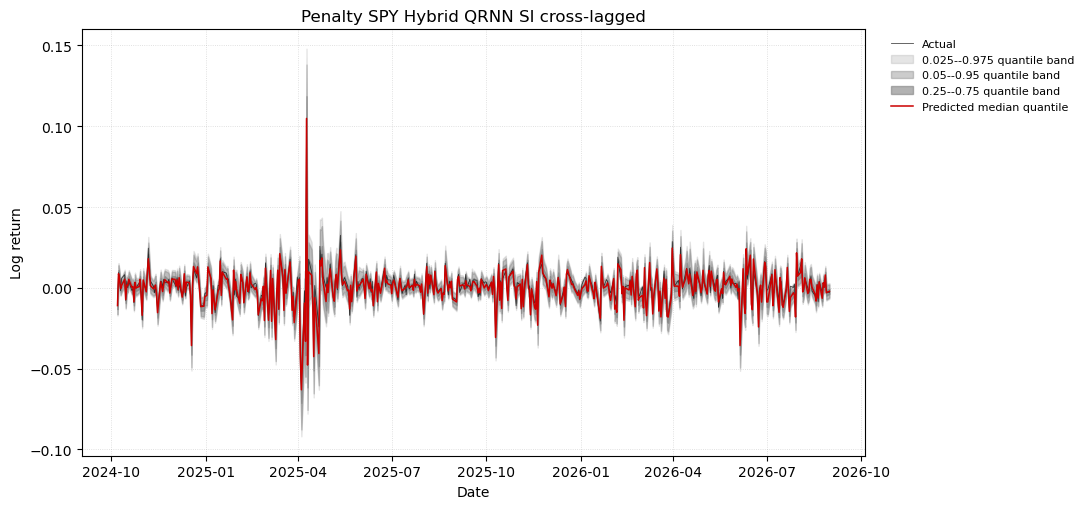


TEST RESULTS — PENALTY SPY QRNN SI CROSS-LAGGED
     alpha    test_nll   hit_rate        hre      sigma
0.02500000 -3.77483058 0.00210084 0.02289916 0.00020146
0.05000000 -3.89349818 0.01680672 0.03319328 0.00033968
0.25000000 -4.19357109 0.13865547 0.11134453 0.00102235
0.50000000 -4.36313200 0.39915967 0.10084033 0.00129827
0.75000000 -4.32509661 0.74159664 0.00840336 0.00106566
0.95000000 -3.95081711 0.97058821 0.02058822 0.00037132
0.97500000 -3.79569077 0.98529410 0.01029408 0.00022152

SUMMARY
Selected trial:       #131
Selected lambda:      0.01
Average test NLL:     -4.042377
Average test HRE:     0.043938
Test crossover:       1 (0.04%)
Test tail violations: 1 (0.11%)

Saved outputs:
  spy_penalty_crossover_results/spy_qrnn_si_cross/penalty_spy_qrnn_si_cross_ranking.csv
  spy_penalty_crossover_results/spy_qrnn_si_cross/penalty_spy_qrnn_si_cross_best.pt
  spy_penalty_crossover_results/spy_qrnn_si_cross/penalty_spy_qrnn_si_cross_test_predictions.csv
  spy_penalty_crossover_resu

In [26]:
# ------------------------------------------------------------
# 16. Plot final test forecasts
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 5.2))

if "test_df" in globals() and len(test_df) == len(y_test):
    plot_axis = test_df.index
    x_label = "Date"
else:
    plot_axis = np.arange(len(y_test))
    x_label = "Test-period observation"

actual_values = y_test.detach().cpu().numpy()
forecast_values = q_penalty_test.detach().cpu().numpy()

def penalty_level_values(level):
    return forecast_values[:, PENALTY_ALPHA_LEVELS.index(level)]

ax.plot(
    plot_axis,
    actual_values,
    color="#000000",
    linewidth=0.6,
    alpha=0.70,
    label="Actual",
)
ax.fill_between(
    plot_axis,
    penalty_level_values(0.025),
    penalty_level_values(0.975),
    color="#808080",
    alpha=0.20,
    label="0.025--0.975 quantile band",
)
ax.fill_between(
    plot_axis,
    penalty_level_values(0.050),
    penalty_level_values(0.950),
    color="#808080",
    alpha=0.40,
    label="0.05--0.95 quantile band",
)
ax.fill_between(
    plot_axis,
    penalty_level_values(0.250),
    penalty_level_values(0.750),
    color="#808080",
    alpha=0.60,
    label="0.25--0.75 quantile band",
)
ax.plot(
    plot_axis,
    penalty_level_values(0.500),
    color="#CC0000",
    linewidth=1.1,
    label="Predicted median quantile",
)

ax.set_xlabel(x_label)
ax.set_ylabel("Log return")
ax.set_title("Penalty SPY Hybrid QRNN SI cross-lagged")
ax.grid(linestyle=":", linewidth=0.6, alpha=0.5)
ax.legend(
    frameon=False,
    fontsize=8,
    ncol=1,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

fig.tight_layout()

penalty_plot_path = (
    PENALTY_OUTPUT_DIR
    / "penalty_spy_qrnn_si_cross_predictions.png"
)

fig.savefig(
    penalty_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------
# 17. Print final results
# ------------------------------------------------------------

print("\n" + "=" * 76)
print("TEST RESULTS — PENALTY SPY QRNN SI CROSS-LAGGED")
print("=" * 76)

print(
    penalty_level_metrics.to_string(
        index=False,
        float_format=lambda value: f"{value:.8f}"
    )
)

print("\n" + "=" * 76)
print("SUMMARY")
print("=" * 76)

print(
    f"Selected trial:       "
    f"#{penalty_best_trial_spy_qrnn_si_cross.number}"
)

print(
    f"Selected lambda:      "
    f"{penalty_best_config_spy_qrnn_si_cross['lambda_cross']}"
)

print(
    f"Average test NLL:     "
    f"{penalty_average_test_nll:.6f}"
)

print(
    f"Average test HRE:     "
    f"{penalty_average_test_hre.item():.6f}"
)

print(
    f"Test crossover:       "
    f"{penalty_test_crossover['total_count']} "
    f"({penalty_test_crossover['total_rate']:.2%})"
)

print(
    f"Test tail violations: "
    f"{penalty_test_crossover['tail_count']} "
    f"({penalty_test_crossover['tail_rate']:.2%})"
)

print("\nSaved outputs:")

for saved_path in [
    penalty_ranking_path,
    penalty_checkpoint_path,
    penalty_predictions_path,
    penalty_level_metrics_path,
    penalty_summary_path,
    penalty_plot_path
]:
    print(f"  {saved_path}")
